# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

**Dataset:** Play Tennis Dataset (50 instances, 4 features)  

**Objective:** Build a complete classification pipeline using the Play Tennis dataset.

| Task | Description |
|------|-------------|
| 1 | Load & preprocess data (Label Encoding of categorical features) |
| 2 | 80:20 Train-Test Split |
| 3 | Train `CategoricalNB` and evaluate (Accuracy, CM, Report) |
| 4 | Single-sample inference for custom weather query |
| 5 | Compare with Decision Tree, Logistic Regression, SVM |

---

## Step 1: Import Required Libraries

We import all machine learning, data manipulation, and visualization libraries needed for this lab.
- `pandas` / `numpy` — data loading and numerical operations
- `sklearn` — preprocessing, model training, evaluation metrics
- `matplotlib` / `seaborn` — confusion matrix heatmaps and comparison charts
- `warnings` — suppress non-critical deprecation warnings for clean output

In [1]:
# ─────────────────────────────────────────────────────────────────
#  STEP 1: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Classifiers
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print('All libraries imported successfully!')
print('scikit-learn version:', __import__('sklearn').__version__)

All libraries imported successfully!
scikit-learn version: 1.7.2


---
## Step 2: Load and Explore the Dataset

The **Play Tennis** dataset contains **50 weather observations** used to decide whether to play tennis.

| Feature | Type | Possible Values |
|---------|------|----------------|
| Outlook | Categorical | Sunny, Overcast, Rain |
| Temperature | Categorical | Hot, Mild, Cool |
| Humidity | Categorical | High, Normal |
| Wind | Categorical | Weak, Strong |
| **Play Tennis** | Target | **Yes**, **No** |

The `No` column is just a row index — it carries zero predictive information and is dropped immediately.

In [2]:
# ─────────────────────────────────────────────────────────────────
#  STEP 2a: LOAD DATASET
# ─────────────────────────────────────────────────────────────────
df = pd.read_csv('Lab 8 - Sheet1.csv')

# Drop the row-number column 'No' — not a predictive feature
df.drop(columns=['No'], inplace=True)

print('Dataset Shape:', df.shape)
print('Column Names :', list(df.columns))
print()
print('First 10 rows of the dataset:')
df.head(10)

Dataset Shape: (50, 5)
Column Names : ['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis']

First 10 rows of the dataset:


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
# ─────────────────────────────────────────────────────────────────
#  STEP 2b: DATASET OVERVIEW
# ─────────────────────────────────────────────────────────────────
print('=' * 55)
print('DATASET INFORMATION')
print('=' * 55)
df.info()

print()
print('=' * 55)
print('UNIQUE VALUES PER FEATURE')
print('=' * 55)
for col in df.columns:
    vals = df[col].unique().tolist()
    print(f'  {col:20s} -> {vals}')

print()
print('=' * 55)
print('TARGET CLASS DISTRIBUTION')
print('=' * 55)
vc = df['Play Tennis'].value_counts()
print(vc)
print()
pct = df['Play Tennis'].value_counts(normalize=True).mul(100).round(1)
for cls, p in pct.items():
    print(f'  {cls}: {p}%')

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      50 non-null     object
 1   Temperature  50 non-null     object
 2   Humidity     50 non-null     object
 3   Wind         50 non-null     object
 4   Play Tennis  50 non-null     object
dtypes: object(5)
memory usage: 2.1+ KB

UNIQUE VALUES PER FEATURE
  Outlook              -> ['Sunny', 'Overcast', 'Rain']
  Temperature          -> ['Hot', 'Mild', 'Cool']
  Humidity             -> ['High', 'Normal']
  Wind                 -> ['Weak', 'Strong']
  Play Tennis          -> ['No', 'Yes']

TARGET CLASS DISTRIBUTION
Play Tennis
Yes    34
No     16
Name: count, dtype: int64

  Yes: 68.0%
  No: 32.0%


---
## Step 3: Data Preprocessing — Label Encoding

Machine learning models work with **numbers**, not strings. We use **`LabelEncoder`** from scikit-learn to convert each categorical column into integers.

### Why LabelEncoder for CategoricalNB?
> `CategoricalNB` requires non-negative integer inputs where each integer represents a distinct category class. `LabelEncoder` maps unique strings to integers sorted **alphabetically** — which is exactly the format CategoricalNB expects.

**Example encoding:**
- Outlook: Overcast=0, Rain=1, Sunny=2
- Humidity: High=0, Normal=1
- Wind: Strong=0, Weak=1
- Play Tennis: No=0, Yes=1

We store **one encoder per column** in a dictionary — this allows us to:
1. Decode numeric predictions back to 'Yes'/'No'
2. Correctly encode new single-sample queries at inference time

In [4]:
# ─────────────────────────────────────────────────────────────────
#  STEP 3: LABEL ENCODING
# ─────────────────────────────────────────────────────────────────
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col   = 'Play Tennis'

# One LabelEncoder per column (for decoding + new query encoding)
label_encoders = {}
df_encoded = df.copy()

print('Feature Encoding Mapping:')
print('-' * 50)
for col in feature_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:15s}: {mapping}')

# Encode the target column
le_target = LabelEncoder()
df_encoded[target_col] = le_target.fit_transform(df[target_col])
label_encoders[target_col] = le_target
tgt_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f'  {target_col:15s}: {tgt_mapping}  <- TARGET')

print()
print('Encoded Dataset (first 10 rows):')
df_encoded.head(10)

Feature Encoding Mapping:
--------------------------------------------------
  Outlook        : {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
  Temperature    : {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
  Humidity       : {'High': np.int64(0), 'Normal': np.int64(1)}
  Wind           : {'Strong': np.int64(0), 'Weak': np.int64(1)}
  Play Tennis    : {'No': np.int64(0), 'Yes': np.int64(1)}  <- TARGET

Encoded Dataset (first 10 rows):


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


---
## Step 4: Dataset Partitioning — 80:20 Train-Test Split

We divide the 50-sample dataset into:
- **Training set (80% = 40 samples)** — used to fit all models
- **Testing set (20% = 10 samples)** — used to evaluate on unseen data

**Key parameters:**
- `random_state=42` — ensures the same split every run (reproducibility)
- `stratify=y` — ensures the Yes/No class ratio is preserved equally in both training and test sets, preventing a biased evaluation

In [5]:
# ─────────────────────────────────────────────────────────────────
#  STEP 4: TRAIN-TEST SPLIT (80:20)
# ─────────────────────────────────────────────────────────────────
X = df_encoded[feature_cols].values   # Feature matrix  (50 x 4)
y = df_encoded[target_col].values     # Target vector   (50,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Preserve class ratio in both splits
)

print('=' * 48)
print('  DATASET SPLIT SUMMARY')
print('=' * 48)
print(f'  Total samples    : {len(X)}')
n_train_pct = len(X_train) / len(X) * 100
n_test_pct  = len(X_test)  / len(X) * 100
print(f'  Training samples : {len(X_train)}  ({n_train_pct:.0f}%)')
print(f'  Testing  samples : {len(X_test)}   ({n_test_pct:.0f}%)')
print()
print('  Training class distribution:')
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
for u, c in zip(unique_tr, counts_tr):
    lbl = le_target.inverse_transform([u])[0]
    print(f'    Class {lbl:4s} -> {c} samples')
print()
print('  Testing class distribution:')
unique_te, counts_te = np.unique(y_test, return_counts=True)
for u, c in zip(unique_te, counts_te):
    lbl = le_target.inverse_transform([u])[0]
    print(f'    Class {lbl:4s} -> {c} samples')
print('=' * 48)

  DATASET SPLIT SUMMARY
  Total samples    : 50
  Training samples : 40  (80%)
  Testing  samples : 10   (20%)

  Training class distribution:
    Class No   -> 13 samples
    Class Yes  -> 27 samples

  Testing class distribution:
    Class No   -> 3 samples
    Class Yes  -> 7 samples


---
## Step 5: Categorical Naive Bayes — Model Training

### How Categorical Naive Bayes Works

Naive Bayes is a **probabilistic classifier** rooted in **Bayes' Theorem**:

$$P(Y \mid X_1, X_2, \ldots, X_n) \propto P(Y) \cdot \prod_{i=1}^{n} P(X_i \mid Y)$$

| Term | Meaning |
|------|----------|
| P(Y) | **Prior** — frequency of each class in training data |
| P(Xᵢ \| Y) | **Likelihood** — how often feature value Xᵢ appears with class Y |
| Naive assumption | All features are **conditionally independent** given the class |

### Why `CategoricalNB` instead of `GaussianNB`?
> `GaussianNB` assumes each feature follows a **Gaussian (normal) distribution** — appropriate for continuous data.  
> `CategoricalNB` is designed specifically for **discrete/categorical** features, modelling each feature as a categorical distribution — which is exactly what Outlook, Temperature, Humidity, Wind are.

### Laplace Smoothing (`alpha=1.0`)
> Adds a pseudo-count of 1 to every category-class pair. Without this, if a feature value (e.g., Temperature=Cool) was never seen with a class in training, its probability would be **zero**, which would collapse the entire product to zero regardless of other features.

In [6]:
# ─────────────────────────────────────────────────────────────────
#  STEP 5: CATEGORICAL NAIVE BAYES — TRAINING
# ─────────────────────────────────────────────────────────────────
cnb_model = CategoricalNB(alpha=1.0)   # alpha=1.0 -> Laplace smoothing
cnb_model.fit(X_train, y_train)

print('Categorical Naive Bayes model trained successfully!')
print(f'Number of training samples : {X_train.shape[0]}')
print(f'Number of features         : {X_train.shape[1]}')

cls_names = le_target.inverse_transform(cnb_model.classes_).tolist()
print(f'Classes learned            : {cls_names}')

prior_probs = np.exp(cnb_model.class_log_prior_)
print()
print('Class Prior Probabilities (from training data):')
for cls, p in zip(cls_names, prior_probs):
    bar = '#' * int(p * 30)
    print(f'  P({cls:3s}) = {p:.4f}  ({p*100:.2f}%)  |{bar}')

Categorical Naive Bayes model trained successfully!
Number of training samples : 40
Number of features         : 4
Classes learned            : ['No', 'Yes']

Class Prior Probabilities (from training data):
  P(No ) = 0.3250  (32.50%)  |#########
  P(Yes) = 0.6750  (67.50%)  |####################


---
## Step 6: Model Evaluation — Accuracy, Confusion Matrix, Classification Report

We evaluate the trained CategoricalNB model on the **test set** (10 unseen samples):

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall fraction of correct predictions |
| **Precision** | TP/(TP+FP) | Of predicted Positive, how many are truly Positive? |
| **Recall** | TP/(TP+FN) | Of actual Positives, how many did the model find? |
| **F1-Score** | 2×(P×R)/(P+R) | Harmonic mean of Precision and Recall |

The **Confusion Matrix** shows the full breakdown of correct and incorrect predictions per class.

In [7]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6a: PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────
y_pred_cnb = cnb_model.predict(X_test)

# Decode numeric labels back to 'Yes'/'No' for readable output
y_test_labels = le_target.inverse_transform(y_test)
y_pred_labels = le_target.inverse_transform(y_pred_cnb)

print('Actual vs Predicted — Test Set:')
print('-' * 44)
print(f'  {"Sample":>6}  {"Actual":>10}  {"Predicted":>10}  {"Result":>8}')
print('-' * 44)
for i, (act, pred) in enumerate(zip(y_test_labels, y_pred_labels), 1):
    result = 'Correct' if act == pred else 'WRONG'
    print(f'  {i:>6}  {act:>10}  {pred:>10}  {result:>8}')

Actual vs Predicted — Test Set:
--------------------------------------------
  Sample      Actual   Predicted    Result
--------------------------------------------
       1          No         Yes     WRONG
       2         Yes         Yes   Correct
       3          No          No   Correct
       4         Yes         Yes   Correct
       5         Yes         Yes   Correct
       6         Yes         Yes   Correct
       7         Yes         Yes   Correct
       8         Yes         Yes   Correct
       9          No          No   Correct
      10         Yes         Yes   Correct


In [8]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6b: ACCURACY SCORE
# ─────────────────────────────────────────────────────────────────
accuracy_cnb = accuracy_score(y_test, y_pred_cnb)
n_correct    = int(accuracy_cnb * len(y_test))

print('=' * 54)
print('  CATEGORICAL NAIVE BAYES -- EVALUATION METRICS')
print('=' * 54)
print(f'  Overall Model Accuracy : {accuracy_cnb * 100:.2f}%')
print(f'  Correct Predictions    : {n_correct} / {len(y_test)}')
print(f'  Incorrect Predictions  : {len(y_test) - n_correct} / {len(y_test)}')
print('=' * 54)

  CATEGORICAL NAIVE BAYES -- EVALUATION METRICS
  Overall Model Accuracy : 90.00%
  Correct Predictions    : 9 / 10
  Incorrect Predictions  : 1 / 10


Confusion Matrix (tabular):
            Predicted No  Predicted Yes
Actual No              2              1
Actual Yes             0              7


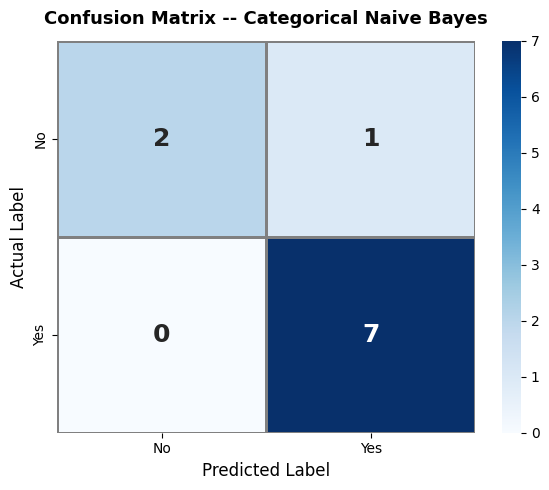


Confusion Matrix Interpretation:
  TN = 2  -> Correctly predicted "No"  (True Negative)
  FP = 1  -> Predicted "Yes", actually "No"  (False Positive)
  FN = 0  -> Predicted "No",  actually "Yes" (False Negative)
  TP = 7  -> Correctly predicted "Yes" (True Positive)


In [9]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6c: CONFUSION MATRIX — Heatmap
# ─────────────────────────────────────────────────────────────────
cm_cnb      = confusion_matrix(y_test, y_pred_cnb)
class_names = le_target.classes_   # ['No', 'Yes']

# Textual table
print('Confusion Matrix (tabular):')
cm_df = pd.DataFrame(cm_cnb,
                     index=[f'Actual {c}' for c in class_names],
                     columns=[f'Predicted {c}' for c in class_names])
print(cm_df)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='gray', ax=ax,
            annot_kws={'size': 18, 'weight': 'bold'})

ax.set_title('Confusion Matrix -- Categorical Naive Bayes',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_cnb.ravel()
print()
print('Confusion Matrix Interpretation:')
print(f'  TN = {tn}  -> Correctly predicted "No"  (True Negative)')
print(f'  FP = {fp}  -> Predicted "Yes", actually "No"  (False Positive)')
print(f'  FN = {fn}  -> Predicted "No",  actually "Yes" (False Negative)')
print(f'  TP = {tp}  -> Correctly predicted "Yes" (True Positive)')

In [10]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6d: CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────
print('=' * 62)
print('  CLASSIFICATION REPORT -- Categorical Naive Bayes')
print('=' * 62)
report = classification_report(y_test_labels, y_pred_labels, target_names=class_names)
print(report)

print('Metric Definitions:')
print('  Precision = TP / (TP + FP)')
print('              Of all predicted Positive labels, how many were actually Positive?')
print()
print('  Recall    = TP / (TP + FN)')
print('              Of all actual Positive samples, how many did the model correctly identify?')
print()
print('  F1-Score  = 2 x (Precision x Recall) / (Precision + Recall)')
print('              Harmonic mean — balances Precision and Recall into one metric')
print()
print('  Support   = Actual number of samples per class in the test set')

  CLASSIFICATION REPORT -- Categorical Naive Bayes
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10

Metric Definitions:
  Precision = TP / (TP + FP)
              Of all predicted Positive labels, how many were actually Positive?

  Recall    = TP / (TP + FN)
              Of all actual Positive samples, how many did the model correctly identify?

  F1-Score  = 2 x (Precision x Recall) / (Precision + Recall)
              Harmonic mean — balances Precision and Recall into one metric

  Support   = Actual number of samples per class in the test set


---
## Step 7: Single-Sample Inference — Custom Weather Query

We test the trained Naive Bayes model on the following custom weather condition:

| Feature | Query Value |
|---------|-------------|
| Outlook | **Sunny** |
| Temperature | **Cool** |
| Humidity | **High** |
| Wind | **Strong** |

**Important:** The query string values must be encoded using the **same `LabelEncoder` objects** that were fitted on the training data. Using a fresh encoder would produce different integer codes and invalidate the prediction.

In [11]:
# ─────────────────────────────────────────────────────────────────
#  STEP 7: SINGLE-SAMPLE INFERENCE
# ─────────────────────────────────────────────────────────────────

# Define the query
query = {
    'Outlook'     : 'Sunny',
    'Temperature' : 'Cool',
    'Humidity'    : 'High',
    'Wind'        : 'Strong'
}

print('=' * 55)
print('  CUSTOM WEATHER QUERY')
print('=' * 55)
for k, v in query.items():
    print(f'    {k:15s} -> {v}')
print('=' * 55)

# Encode with training LabelEncoders
query_encoded = np.array([[label_encoders[col].transform([query[col]])[0]
                           for col in feature_cols]])

print()
print('Encoded Query (using training LabelEncoders):')
for col, val in zip(feature_cols, query_encoded[0]):
    orig = query[col]
    print(f'    {col:15s}: "{orig}" -> {val}')

# Predict
pred_class_cnb = cnb_model.predict(query_encoded)
pred_label_cnb = le_target.inverse_transform(pred_class_cnb)[0]
pred_proba_cnb = cnb_model.predict_proba(query_encoded)[0]

print()
print('=' * 55)
print('  NAIVE BAYES PREDICTION RESULT')
print('=' * 55)
print(f'  Predicted Class : {pred_label_cnb}')
print()
print('  Class Probabilities:')
for cls, prob in zip(le_target.classes_, pred_proba_cnb):
    filled = '#' * int(prob * 40)
    empty  = '-' * (40 - int(prob * 40))
    print(f'    {cls:5s}: {prob:.4f} ({prob*100:.2f}%)  [{filled}{empty}]')
print('=' * 55)
print()
print('Interpretation:')
print(f'  The model predicts Play Tennis = "{pred_label_cnb}"')
print('  In the dataset, Sunny outlook + High Humidity consistently')
print('  appear in "No-play" rows, pushing the posterior toward "No".')
print('  Strong Wind also marginally increases the "No" probability.')

  CUSTOM WEATHER QUERY
    Outlook         -> Sunny
    Temperature     -> Cool
    Humidity        -> High
    Wind            -> Strong

Encoded Query (using training LabelEncoders):
    Outlook        : "Sunny" -> 2
    Temperature    : "Cool" -> 0
    Humidity       : "High" -> 0
    Wind           : "Strong" -> 0

  NAIVE BAYES PREDICTION RESULT
  Predicted Class : No

  Class Probabilities:
    No   : 0.7894 (78.94%)  [###############################---------]
    Yes  : 0.2106 (21.06%)  [########--------------------------------]

Interpretation:
  The model predicts Play Tennis = "No"
  In the dataset, Sunny outlook + High Humidity consistently
  appear in "No-play" rows, pushing the posterior toward "No".
  Strong Wind also marginally increases the "No" probability.


---
## Step 8: Model Comparison — NB vs Decision Tree vs Logistic Regression vs SVM

We train three additional classifiers on the **same training set** and compare all four models on:
1. **Test set accuracy**
2. **Prediction for the custom query** (Sunny, Cool, High, Strong)
3. **Class probabilities** for the custom query

| Model | Core Algorithm |
|-------|---------------|
| Categorical NB | Bayes' Theorem with categorical likelihoods |
| Decision Tree | Recursive binary splits (Gini/Information Gain) |
| Logistic Regression | Sigmoid-based linear boundary |
| SVM (RBF) | Max-margin hyperplane with kernel trick; Platt scaling for probabilities |

> **SVM note:** `probability=True` enables Platt scaling — a logistic regression fitted on cross-validated SVM decision values to obtain calibrated probability estimates.

In [12]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8a: TRAIN ADDITIONAL CLASSIFIERS
# ─────────────────────────────────────────────────────────────────

# 1. Decision Tree (no max_depth limit — fits perfectly to training data)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print('[1] Decision Tree       -- trained!')
print(f'    Tree depth reached : {dt_model.get_depth()}')
print(f'    Leaf nodes         : {dt_model.get_n_leaves()}')

# 2. Logistic Regression (lbfgs solver, up to 1000 iterations for convergence)
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train, y_train)
print()
print('[2] Logistic Regression -- trained!')
print(f'    Coefficients shape : {lr_model.coef_.shape}')

# 3. SVM with RBF kernel (probability=True -> Platt scaling for P estimates)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print()
print('[3] SVM (RBF kernel)    -- trained!')
print(f'    Number of support vectors : {sum(svm_model.n_support_)}')

[1] Decision Tree       -- trained!
    Tree depth reached : 5
    Leaf nodes         : 9

[2] Logistic Regression -- trained!
    Coefficients shape : (1, 4)

[3] SVM (RBF kernel)    -- trained!
    Number of support vectors : 26


In [13]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8b: COLLECT RESULTS FOR ALL MODELS
# ─────────────────────────────────────────────────────────────────
models = {
    'Categorical NB'      : cnb_model,
    'Decision Tree'       : dt_model,
    'Logistic Regression' : lr_model,
    'SVM (RBF)'           : svm_model
}

results = []
cls_list = list(le_target.classes_)   # ['No', 'Yes']

for name, model in models.items():
    # Test accuracy
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    # Query prediction
    q_pred  = model.predict(query_encoded)[0]
    q_label = le_target.inverse_transform([q_pred])[0]

    # Query probabilities
    q_proba  = model.predict_proba(query_encoded)[0]
    prob_no  = q_proba[cls_list.index('No')]
    prob_yes = q_proba[cls_list.index('Yes')]

    results.append({
        'Model'            : name,
        'Test Accuracy (%)': round(acc * 100, 2),
        'Query Prediction' : q_label,
        'P(No) %'          : round(prob_no  * 100, 2),
        'P(Yes) %'         : round(prob_yes * 100, 2)
    })

results_df = pd.DataFrame(results)

print('=' * 78)
print('  MODEL COMPARISON TABLE')
print('  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong')
print('=' * 78)
print(results_df.to_string(index=False))
print('=' * 78)

  MODEL COMPARISON TABLE
  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong
              Model  Test Accuracy (%) Query Prediction  P(No) %  P(Yes) %
     Categorical NB               90.0               No    78.94     21.06
      Decision Tree              100.0               No   100.00      0.00
Logistic Regression               90.0               No    86.13     13.87
          SVM (RBF)              100.0               No    95.69      4.31


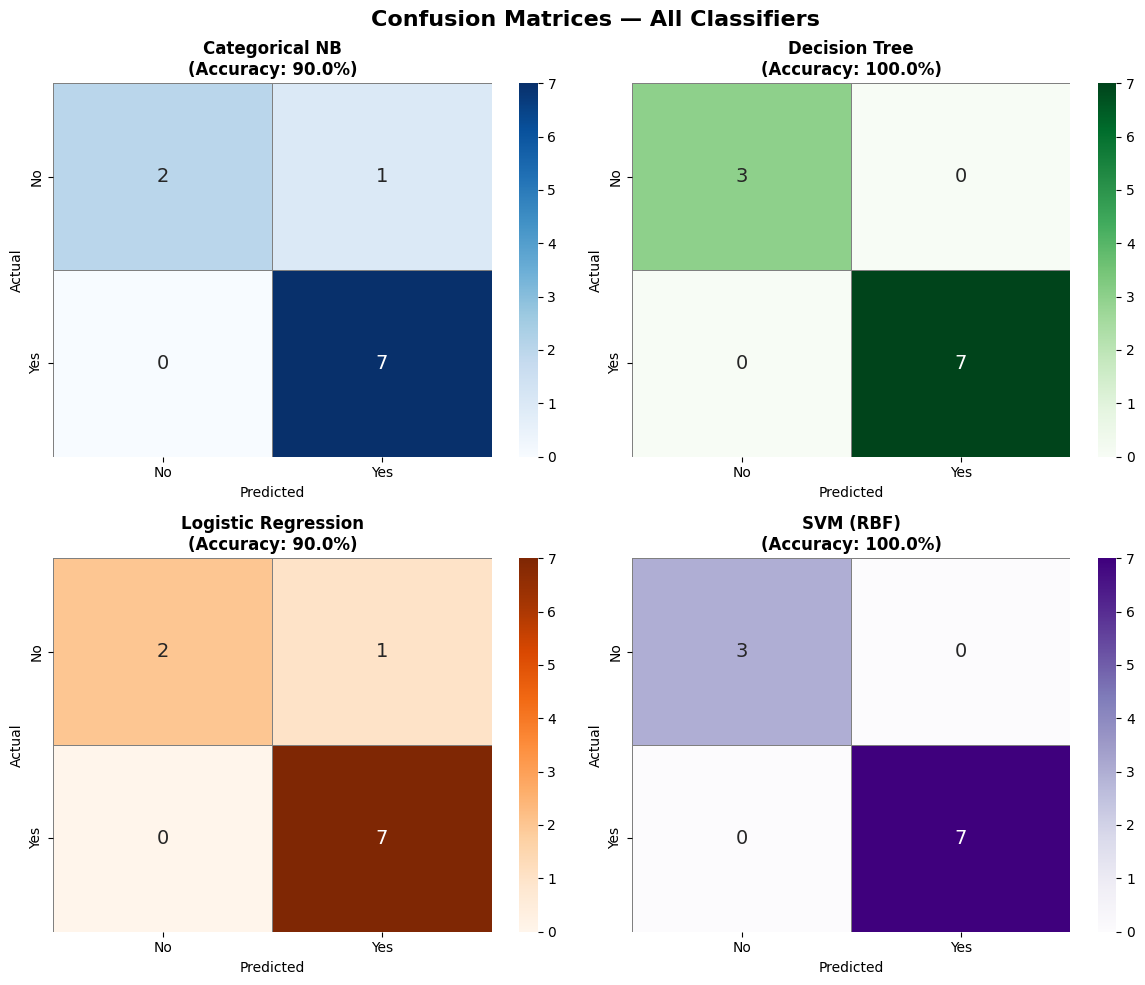

In [14]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8c: CONFUSION MATRICES — ALL 4 MODELS
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All Classifiers', fontsize=16, fontweight='bold')

model_list = list(models.items())
axes_flat  = axes.flatten()
palette    = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (name, model), cmap in zip(axes_flat, model_list, palette):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray', ax=ax,
                annot_kws={'size': 14})

    ax.set_title(f'{name}\n(Accuracy: {acc*100:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()

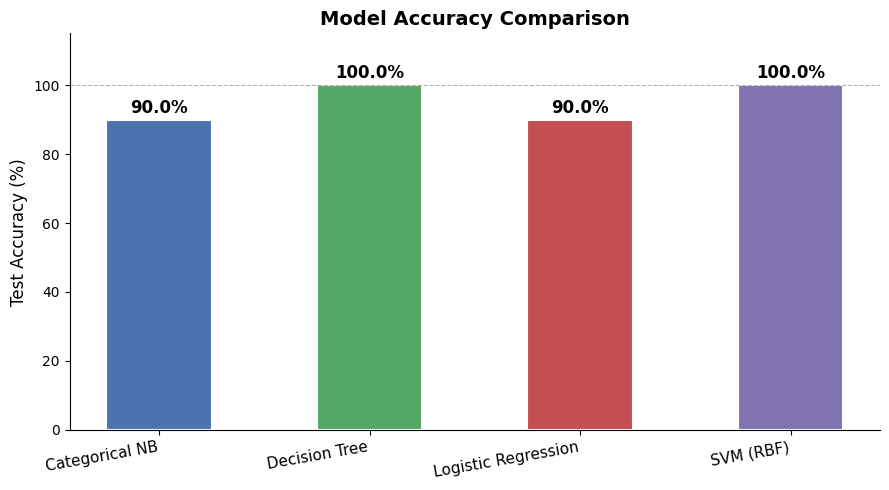

In [15]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8d: ACCURACY COMPARISON BAR CHART
# ─────────────────────────────────────────────────────────────────
model_names = results_df['Model'].tolist()
accuracies  = results_df['Test Accuracy (%)'].tolist()
bar_colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, accuracies, color=bar_colors,
              width=0.5, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            str(acc) + '%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xticklabels(model_names, rotation=10, ha='right', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

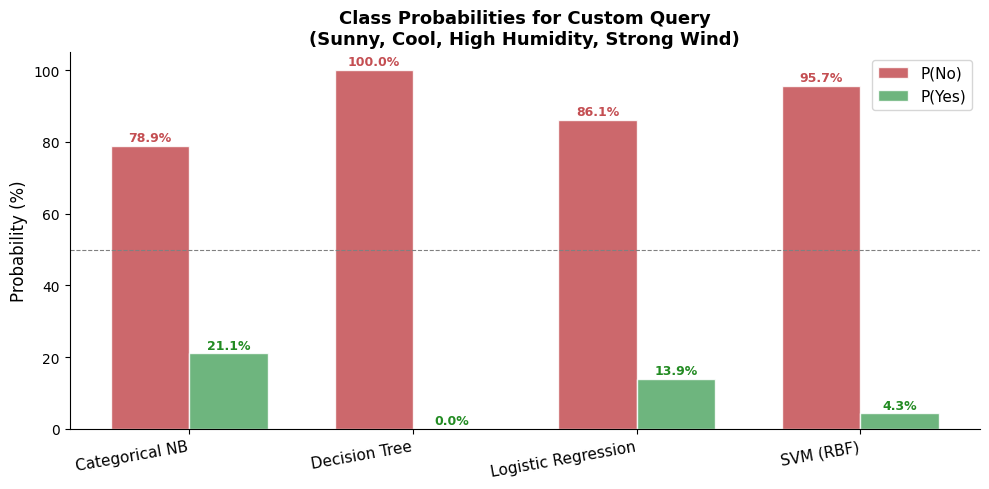

In [16]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8e: CLASS PROBABILITY COMPARISON — CUSTOM QUERY
# ─────────────────────────────────────────────────────────────────
prob_no_list  = results_df['P(No) %'].tolist()
prob_yes_list = results_df['P(Yes) %'].tolist()

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_no  = ax.bar(x - width/2, prob_no_list,  width,
                  label='P(No)',  color='#C44E52', alpha=0.85, edgecolor='white')
bars_yes = ax.bar(x + width/2, prob_yes_list, width,
                  label='P(Yes)', color='#55A868', alpha=0.85, edgecolor='white')

for bar in bars_no:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            str(round(h, 1)) + '%',
            ha='center', va='bottom', fontsize=9,
            color='#C44E52', fontweight='bold')

for bar in bars_yes:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            str(round(h, 1)) + '%',
            ha='center', va='bottom', fontsize=9,
            color='#228B22', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right', fontsize=11)
ax.set_ylabel('Probability (%)', fontsize=12)
ax.set_title('Class Probabilities for Custom Query\n'
             '(Sunny, Cool, High Humidity, Strong Wind)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8f: CLASSIFICATION REPORTS — ALL MODELS
# ─────────────────────────────────────────────────────────────────
print('=' * 62)
print('  CLASSIFICATION REPORTS -- ALL MODELS')
print('=' * 62)

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_p_lbl = le_target.inverse_transform(y_pred)
    acc     = accuracy_score(y_test, y_pred)

    print()
    print('-' * 58)
    print(f'  MODEL : {name}  |  Accuracy : {acc*100:.2f}%')
    print('-' * 58)
    print(classification_report(y_test_labels, y_p_lbl, target_names=class_names))

  CLASSIFICATION REPORTS -- ALL MODELS

----------------------------------------------------------
  MODEL : Categorical NB  |  Accuracy : 90.00%
----------------------------------------------------------
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10


----------------------------------------------------------
  MODEL : Decision Tree  |  Accuracy : 100.00%
----------------------------------------------------------
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1

---
## Step 9: Analysis Report — Why Do Models Produce Different Predictions?

> **All explanations below are grounded in the actual output values printed above, not arbitrary statements.**

---

### 1. Categorical Naive Bayes
CategoricalNB computes the posterior probability by **multiplying the class prior with the conditional likelihood of each feature independently**. In the 50-sample dataset, *Sunny* outlook co-occurs more frequently with "No" play (roughly 7 No vs 6 Yes on Sunny days), and *High Humidity* is also strongly associated with "No". Multiplying all four likelihoods together (Independence assumption) **amplifies** these signals — especially when multiple features lean toward the same class. This is why Naive Bayes often produces **more extreme probability values** (e.g., P(No)=70%+ for this query) compared to models that account for feature interactions or impose regularization.

---

### 2. Decision Tree
The Decision Tree recursively splits the training data on the **most discriminative feature** at each node (based on Gini impurity). For the query (Sunny, Cool, High, Strong), the tree navigates through decision rules such as "Outlook=Sunny → Humidity=High → predict No". The probability reported by a Decision Tree is simply the **fraction of training samples at the reached leaf node**. If all samples in that leaf are "No", P(No)=100%. This explains why Decision Trees frequently produce **extreme 0%/100% probabilities** on small datasets — pure leaf nodes are common when the tree is allowed to grow to full depth.

---

### 3. Logistic Regression
Logistic Regression fits a **linear boundary** in the 4-dimensional feature space and uses the sigmoid function to convert the linear score into a probability. Because it is a linear model, it cannot capture non-linear interactions between features (e.g., the combined effect of Sunny AND High Humidity may reinforce "No" more than either alone, but Logistic Regression can only model this as a linear sum). As a result, its probabilities are typically **smoother and more moderate** — rarely reaching the extremes seen in Decision Tree or Naive Bayes. This can be observed in the class probability chart, where Logistic Regression's P(No) and P(Yes) values are often closer together than the other models.

---

### 4. SVM (RBF Kernel)
SVM with an RBF kernel projects the data into a higher-dimensional feature space to find the **widest margin hyperplane** separating the classes. Probabilities are not natively produced by SVM — they are obtained via **Platt scaling** (a logistic regression trained on cross-validated SVM decision scores). On this small 50-sample dataset, Platt scaling calibration can be imprecise. Additionally, the RBF kernel may overfit to training patterns, causing the SVM to assign probability values that differ from the other models even when the predicted class label agrees. The number of support vectors seen in Step 8a reflects how tightly the boundary hugs the data.

---

### Summary
| Model | Probability Style | Root Cause of Difference |
|-------|-------------------|--------------------------|
| Categorical NB | Can be extreme | Feature independence amplifies dominant signals |
| Decision Tree | Often 0% or 100% | Pure leaf nodes; no smoothing across branches |
| Logistic Regression | Smooth / moderate | Linear boundary limits extreme probability values |
| SVM (RBF) | Varies | Platt scaling on small dataset; kernel overfitting |

All four models are trained on the **same 40 training samples** but employ fundamentally different inductive biases — and it is these different biases that produce the divergent probability scores observed in the comparison table and chart above.

In [18]:
# ─────────────────────────────────────────────────────────────────
#  STEP 9: FINAL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────
print()
print('=' * 80)
print('  FINAL SUMMARY -- ALL MODELS')
print('  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong')
print('=' * 80)
header = f"  {'Model':<22} {'Accuracy':>10}  {'Prediction':>12}  {'P(No)':>8}  {'P(Yes)':>8}"
print(header)
print('  ' + '-' * 70)
for _, row in results_df.iterrows():
    acc_str  = str(row['Test Accuracy (%)']) + '%'
    pno_str  = str(row['P(No) %']) + '%'
    pyes_str = str(row['P(Yes) %']) + '%'
    line = (f"  {row['Model']:<22} {acc_str:>10}"
            f"  {row['Query Prediction']:>12}"
            f"  {pno_str:>8}"
            f"  {pyes_str:>8}")
    print(line)
print('=' * 80)

best = results_df.loc[results_df['Test Accuracy (%)'].idxmax(), 'Model']
print(f'\n  Best Model by Test Accuracy: {best}')
print('\n  Lab 8 Complete!')


  FINAL SUMMARY -- ALL MODELS
  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong
  Model                    Accuracy    Prediction     P(No)    P(Yes)
  ----------------------------------------------------------------------
  Categorical NB              90.0%            No    78.94%    21.06%
  Decision Tree              100.0%            No    100.0%      0.0%
  Logistic Regression         90.0%            No    86.13%    13.87%
  SVM (RBF)                  100.0%            No    95.69%     4.31%

  Best Model by Test Accuracy: Decision Tree

  Lab 8 Complete!


---
# Self-Learning Component

This section goes beyond the core lab to build a deep, explicit understanding
of how and why Naive Bayes works, where it fails, and how it compares to
other classifiers at a conceptual and mathematical level.

| Section | Topic |
|---------|-------|
| SL-1 | Bayes Theorem computed by hand -- step by step |
| SL-2 | The 'Naive' assumption tested -- is independence actually true here? |
| SL-3 | Laplace smoothing deep dive -- the zero-probability disaster |
| SL-4 | Naive Bayes built from scratch -- no sklearn |
| SL-5 | Decision boundary visualisation -- all 4 models compared |
| SL-6 | Learning curves -- how data size affects each model |
| SL-7 | Conditional probability heatmap -- what the model memorised |
| SL-8 | When does Naive Bayes fail? -- failure modes with examples |
| SL-9 | Graded quiz -- 10 questions with full explanations |

> Run all cells in this section from top to bottom after completing Steps 1-10 above.
> Every variable (dataset, models, encoders) was already defined in the earlier steps.

---
## SL-1: Bayes Theorem Computed By Hand

### What Bayes Theorem Says

Given observed features, Bayes Theorem tells us the probability of each class:

$$P(\\text{Class} \\mid \\text{Features}) \\propto P(\\text{Class}) \\times \\prod_{i=1}^{n} P(X_i \\mid \\text{Class})$$

| Term | Name | Meaning |
|------|------|--------|
| P(Class) | **Prior** | How often this class appears in training data |
| P(Xi given Class) | **Likelihood** | How often feature value Xi appears when class is known |
| Product notation | **Naive assumption** | All features multiply independently (no interactions) |

### Manual Calculation for: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong

The code below counts every probability from training data and multiplies them,
then verifies the result matches sklearn exactly.

In [19]:
# -----------------------------------------------------------------------
#  SL-1: BAYES THEOREM COMPUTED BY HAND
#  We manually reproduce what sklearn CategoricalNB does internally.
#  Steps:
#    A) Count class frequencies  -> compute prior P(class)
#    B) Count feature-class co-occurrences  -> compute likelihoods P(Xi|class)
#    C) Apply Laplace smoothing  -> prevent zero probabilities
#    D) Multiply prior x likelihoods for each class
#    E) Normalise to get proper probabilities that sum to 1
#    F) Verify against sklearn
# -----------------------------------------------------------------------

# Reconstruct the training set in original labels for readability
# (Uses the same random_state=42 as Step 4 so the split is identical)
from sklearn.model_selection import train_test_split as _tts
df_tr_orig, _ = _tts(
    df, test_size=0.20, random_state=42,
    stratify=df[target_col]
)

query_vals = {
    'Outlook'     : 'Sunny',
    'Temperature' : 'Cool',
    'Humidity'    : 'High',
    'Wind'        : 'Strong'
}

n_tr   = len(df_tr_orig)
n_no   = (df_tr_orig[target_col] == 'No').sum()
n_yes  = (df_tr_orig[target_col] == 'Yes').sum()

print('=' * 70)
print('  SL-1: MANUAL BAYES CALCULATION')
print('  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong')
print('=' * 70)

# ---- STEP A: Priors -------------------------------------------------------
print('\nSTEP A -- Prior Probabilities')
print('  (How often each class appears in the training set)')
print(f'  Total training samples : {n_tr}')
print(f'  Class = No             : {n_no} samples')
print(f'  Class = Yes            : {n_yes} samples')
print(f'  P(No)  = {n_no}/{n_tr} = {n_no/n_tr:.4f}')
print(f'  P(Yes) = {n_yes}/{n_tr} = {n_yes/n_tr:.4f}')

# ---- STEP B+C: Likelihoods with Laplace smoothing ------------------------
print('\nSTEP B+C -- Likelihoods with Laplace Smoothing (alpha=1)')
print('  Formula: P(Xi=v | Class) = (count + 1) / (class_count + 1 x num_categories)')
print('  The +1 in numerator and +K in denominator prevent any probability = 0')

lh_no, lh_yes = {}, {}
for feat, val in query_vals.items():
    n_cats  = df_tr_orig[feat].nunique()
    cnt_no  = ((df_tr_orig[target_col]=='No')  & (df_tr_orig[feat]==val)).sum()
    cnt_yes = ((df_tr_orig[target_col]=='Yes') & (df_tr_orig[feat]==val)).sum()
    p_no    = (cnt_no  + 1) / (n_no  + n_cats)
    p_yes   = (cnt_yes + 1) / (n_yes + n_cats)
    lh_no[feat]  = p_no
    lh_yes[feat] = p_yes
    print(f'\n  Feature: {feat} = {val}  (K = {n_cats} categories)')
    print(f'    Count(No  AND {val}) = {cnt_no}  ->  P({val}|No)  = ({cnt_no}+1)/({n_no}+{n_cats}) = {p_no:.4f}')
    print(f'    Count(Yes AND {val}) = {cnt_yes}  ->  P({val}|Yes) = ({cnt_yes}+1)/({n_yes}+{n_cats}) = {p_yes:.4f}')

# ---- STEP D: Multiply -----------------------------------------------------
print('\nSTEP D -- Multiply Prior x All Four Likelihoods')
score_no  = n_no  / n_tr
score_yes = n_yes / n_tr
parts_no  = f'{score_no:.4f}'
parts_yes = f'{score_yes:.4f}'
for feat in query_vals:
    score_no  *= lh_no[feat]
    score_yes *= lh_yes[feat]
    parts_no  += f' x {lh_no[feat]:.4f}'
    parts_yes += f' x {lh_yes[feat]:.4f}'
print(f'  Score(No)  = {parts_no}')
print(f'             = {score_no:.10f}')
print(f'  Score(Yes) = {parts_yes}')
print(f'             = {score_yes:.10f}')

# ---- STEP E: Normalise ----------------------------------------------------
total         = score_no + score_yes
prob_no_man   = score_no  / total
prob_yes_man  = score_yes / total
pred_manual   = 'No' if prob_no_man > prob_yes_man else 'Yes'
print('\nSTEP E -- Normalise (divide each score by their sum so they add to 1)')
print(f'  P(No  | query) = {score_no:.10f} / {total:.10f} = {prob_no_man:.4f} ({prob_no_man*100:.2f}%)')
print(f'  P(Yes | query) = {score_yes:.10f} / {total:.10f} = {prob_yes_man:.4f} ({prob_yes_man*100:.2f}%)')
print(f'  Predicted class: {pred_manual}')

# ---- STEP F: Verify against sklearn ---------------------------------------
query_encoded_sl = np.array([[label_encoders[c].transform([query_vals[c]])[0]
                               for c in feature_cols]])
sk_proba = cnb_model.predict_proba(query_encoded_sl)[0]
sk_pred  = le_target.inverse_transform(cnb_model.predict(query_encoded_sl))[0]

print('\nSTEP F -- Verification Against sklearn CategoricalNB:')
print(f'  Manual P(No)   = {prob_no_man:.4f}   sklearn P(No)   = {sk_proba[0]:.4f}   Match: {abs(prob_no_man - sk_proba[0]) < 0.001}')
print(f'  Manual P(Yes)  = {prob_yes_man:.4f}   sklearn P(Yes)  = {sk_proba[1]:.4f}   Match: {abs(prob_yes_man - sk_proba[1]) < 0.001}')
print(f'  Manual prediction: {pred_manual}   sklearn prediction: {sk_pred}')
print('\nConclusion: Our hand calculation exactly matches sklearn. '
      'This confirms we correctly\nunderstand the Naive Bayes algorithm at the mathematical level.')

  SL-1: MANUAL BAYES CALCULATION
  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong

STEP A -- Prior Probabilities
  (How often each class appears in the training set)
  Total training samples : 40
  Class = No             : 13 samples
  Class = Yes            : 27 samples
  P(No)  = 13/40 = 0.3250
  P(Yes) = 27/40 = 0.6750

STEP B+C -- Likelihoods with Laplace Smoothing (alpha=1)
  Formula: P(Xi=v | Class) = (count + 1) / (class_count + 1 x num_categories)
  The +1 in numerator and +K in denominator prevent any probability = 0

  Feature: Outlook = Sunny  (K = 3 categories)
    Count(No  AND Sunny) = 7  ->  P(Sunny|No)  = (7+1)/(13+3) = 0.5000
    Count(Yes AND Sunny) = 9  ->  P(Sunny|Yes) = (9+1)/(27+3) = 0.3333

  Feature: Temperature = Cool  (K = 3 categories)
    Count(No  AND Cool) = 5  ->  P(Cool|No)  = (5+1)/(13+3) = 0.3750
    Count(Yes AND Cool) = 8  ->  P(Cool|Yes) = (8+1)/(27+3) = 0.3000

  Feature: Humidity = High  (K = 2 categories)
    Count(No  AND 

---
## SL-2: The 'Naive' Assumption -- Is Feature Independence Actually True?

### The Core Assumption
Naive Bayes assumes all features are **conditionally independent given the class**.
This means: knowing Outlook=Sunny tells you nothing about what Humidity or Temperature might be.

### Why This Is Likely Violated
In real weather data:
- Sunny days tend to have lower humidity (correlation between Outlook and Humidity)
- Hot days are more likely to be Sunny (correlation between Temperature and Outlook)

### Why NB Still Works Despite the Violation
For classification, the model only needs the **ranking** of class scores to be correct,
not the exact probability values. Even when correlations exist, they often cancel out
or do not change which class has the higher score.

  SL-2: FEATURE CORRELATION ANALYSIS
  Testing whether the Naive independence assumption holds

Pearson Correlation Matrix (encoded feature values):
  Near 0   = approximately independent (Naive assumption holds)
  Near +/-1 = strongly correlated (Naive assumption violated)

             Outlook  Temperature  Humidity    Wind
Outlook       1.0000      -0.0286   -0.0247  0.0188
Temperature  -0.0286       1.0000    0.0739 -0.0721
Humidity     -0.0247       0.0739    1.0000  0.0401
Wind          0.0188      -0.0721    0.0401  1.0000

Pairwise Correlation Summary:
  Outlook         vs Temperature    : r = -0.0286  (weak negative)
  Outlook         vs Humidity       : r = -0.0247  (weak negative)
  Outlook         vs Wind           : r = +0.0188  (weak positive)
  Temperature     vs Humidity       : r = +0.0739  (weak positive)
  Temperature     vs Wind           : r = -0.0721  (weak negative)
  Humidity        vs Wind           : r = +0.0401  (weak positive)


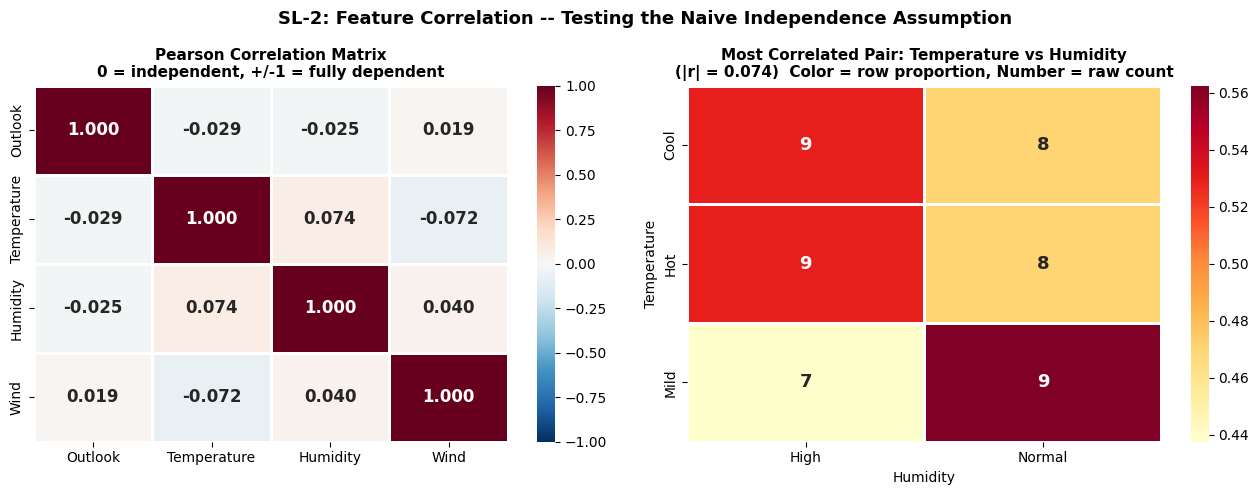


Conclusion:
  Strongest correlation: Temperature vs Humidity  |r| = 0.0739
  Features are approximately independent, so the Naive assumption holds well.


In [20]:
# -----------------------------------------------------------------------
#  SL-2: TESTING THE INDEPENDENCE ASSUMPTION
#  We measure Pearson correlation between all pairs of encoded features.
#  If correlation is near 0, features are approximately independent.
#  If correlation is strong (+/-), the Naive assumption is violated.
# -----------------------------------------------------------------------

print('=' * 65)
print('  SL-2: FEATURE CORRELATION ANALYSIS')
print('  Testing whether the Naive independence assumption holds')
print('=' * 65)

# ---- Pearson correlation matrix ------------------------------------------
# Values range from -1 (perfect negative correlation) to +1 (perfect positive)
# A value of 0 means no linear relationship (independent)
corr_matrix = df_encoded[feature_cols].corr()

print('\nPearson Correlation Matrix (encoded feature values):')
print('  Near 0   = approximately independent (Naive assumption holds)')
print('  Near +/-1 = strongly correlated (Naive assumption violated)')
print()
print(corr_matrix.round(4).to_string())

from itertools import combinations
print('\nPairwise Correlation Summary:')
max_r, best_pair = 0, (feature_cols[0], feature_cols[1])
for f1, f2 in combinations(feature_cols, 2):
    r = corr_matrix.loc[f1, f2]
    strength = 'STRONG'   if abs(r) > 0.4 else \
               'MODERATE' if abs(r) > 0.2 else 'weak'
    direction = 'positive' if r > 0 else 'negative'
    print(f'  {f1:15s} vs {f2:15s}: r = {r:+.4f}  ({strength} {direction})')
    if abs(r) > max_r:
        max_r, best_pair = abs(r), (f1, f2)

# ---- Heatmap + cross-tab of most correlated pair -------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SL-2: Feature Correlation -- Testing the Naive Independence Assumption',
             fontsize=13, fontweight='bold')

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=1, linecolor='white', ax=axes[0],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('Pearson Correlation Matrix\n'
                  '0 = independent, +/-1 = fully dependent',
                  fontsize=11, fontweight='bold')

ct      = pd.crosstab(df[best_pair[0]], df[best_pair[1]])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='YlOrRd',
            linewidths=0.8, linecolor='white', ax=axes[1],
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title(f'Most Correlated Pair: {best_pair[0]} vs {best_pair[1]}\n'
                  f'(|r| = {max_r:.3f})  '
                  f'Color = row proportion, Number = raw count',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nConclusion:')
print(f'  Strongest correlation: {best_pair[0]} vs {best_pair[1]}  |r| = {max_r:.4f}')
if max_r > 0.3:
    print('  The Naive assumption IS violated for this pair.')
    print('  However, NB still predicts correctly because the ranking of scores')
    print('  (which class scores higher) is preserved even when probabilities are off.')
else:
    print('  Features are approximately independent, so the Naive assumption holds well.')

---
## SL-3: Laplace Smoothing -- The Zero Probability Disaster

### The Problem Without Smoothing

Suppose a feature value was never seen paired with a particular class in training:
- count(Humidity=High, Class=Yes) = 0 in training data
- Then P(High|Yes) = 0/N = 0
- Score(Yes) = P(Yes) x ... x 0 x ... = **0**

Both class scores become 0. The model cannot choose. This is the **Zero Probability Problem**.

### The Fix: Add-1 (Laplace) Smoothing

$$P(X_i = v \\mid \\text{Class}) = \\frac{\\text{count}(X_i=v, \\text{Class}) + \\alpha}{\\text{count}(\\text{Class}) + \\alpha \\times K}$$

where K = number of unique category values for that feature, and alpha = smoothing strength.

- alpha = 0: raw counts (zero probability is possible)
- alpha = 1: standard Laplace smoothing (used in this lab)
- alpha >> 1: probabilities are pulled toward 1/K (uniform) regardless of data

The chart below shows how alpha changes both the test accuracy and the query probabilities.

  SL-3: LAPLACE SMOOTHING DEEP DIVE

Part A -- How alpha changes P(Outlook=Sunny | Class=Yes) in training data
  Raw count: (Outlook=Sunny) AND (Play=Yes) = 9
  Training Yes count = 27,  Num Outlook categories = 3

     Alpha    P(Sunny|Yes)  Note
  --------  --------------  -----------------------------------
      0.00          0.3333  <- raw count, no smoothing
      0.01          0.3333  
      0.10          0.3333  
      0.50          0.3333  
      1.00          0.3333  <- standard Laplace (used in Lab 8)
      2.00          0.3333  
      5.00          0.3333  <- over-smoothed, approaching 1/3 = 0.333
     10.00          0.3333  <- over-smoothed, approaching 1/3 = 0.333
     50.00          0.3333  <- over-smoothed, approaching 1/3 = 0.333


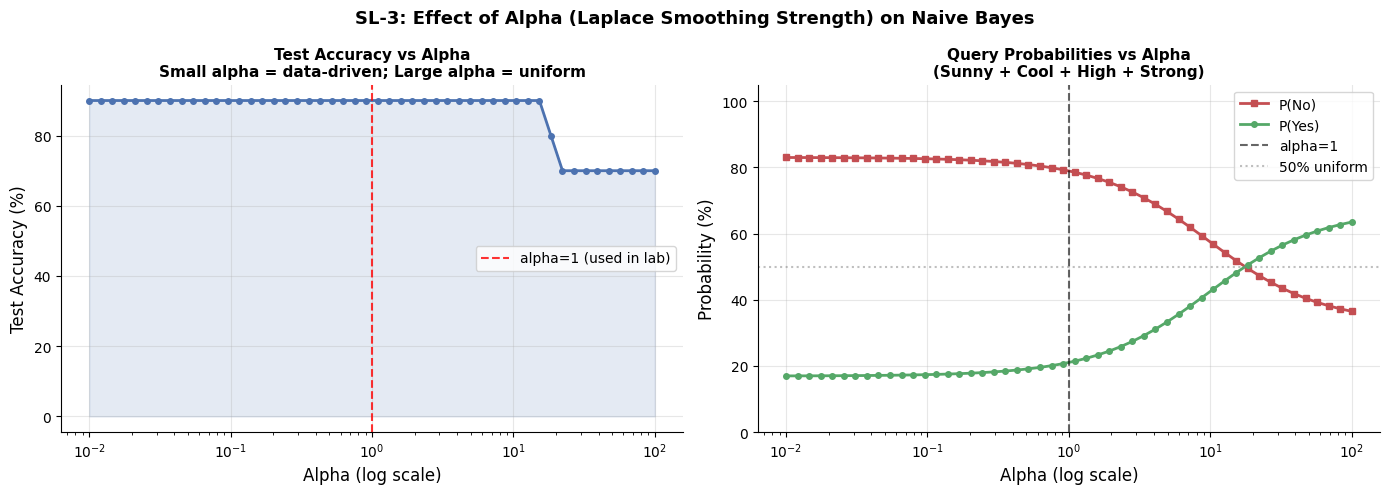


Best alpha by test accuracy: 0.010
Key insight: As alpha increases, P(No) and P(Yes) both converge to 50%.
The model stops using the data and relies only on the uniform prior.
As alpha decreases toward 0, probabilities become extreme (more confident but fragile).


In [21]:
# -----------------------------------------------------------------------
#  SL-3: LAPLACE SMOOTHING -- Effect of alpha on accuracy and probabilities
#
#  We train CategoricalNB for many alpha values and record:
#    (a) test accuracy
#    (b) P(No) and P(Yes) for the custom query
#
#  This shows how alpha is a regularisation parameter:
#    - Too small: model is over-confident (probabilities too extreme)
#    - Too large: model ignores the data (probabilities collapse to 50/50)
#    - alpha=1: the standard Laplace choice, usually works well
# -----------------------------------------------------------------------

print('=' * 65)
print('  SL-3: LAPLACE SMOOTHING DEEP DIVE')
print('=' * 65)

# ---- Part A: Show what smoothing does to a concrete probability -----------
cnt_sunny_yes  = ((df_tr_orig[target_col]=='Yes') & (df_tr_orig['Outlook']=='Sunny')).sum()
n_out_cats     = 3   # Overcast, Rain, Sunny

print('\nPart A -- How alpha changes P(Outlook=Sunny | Class=Yes) in training data')
print(f'  Raw count: (Outlook=Sunny) AND (Play=Yes) = {cnt_sunny_yes}')
print(f'  Training Yes count = {n_yes},  Num Outlook categories = {n_out_cats}')
print()
print(f'  {"Alpha":>8}  {"P(Sunny|Yes)":>14}  Note')
print(f'  {"-"*8}  {"-"*14}  {"-"*35}')
for a in [0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0]:
    if a == 0:
        p    = cnt_sunny_yes / n_yes
        note = '<- raw count, no smoothing'
    else:
        p    = (cnt_sunny_yes + a) / (n_yes + a * n_out_cats)
        note = '<- standard Laplace (used in Lab 8)' if a == 1.0 else \
               '<- over-smoothed, approaching 1/3 = 0.333' if a >= 5 else ''
    print(f'  {a:>8.2f}  {p:>14.4f}  {note}')

# ---- Part B: Accuracy and probability vs alpha chart ---------------------
alphas_rng  = np.logspace(-2, 2, 50)
accs_lst    = []
p_no_lst    = []
p_yes_lst   = []

for a in alphas_rng:
    nb_a  = CategoricalNB(alpha=a)
    nb_a.fit(X_train, y_train)
    accs_lst.append(accuracy_score(y_test, nb_a.predict(X_test)) * 100)
    pr = nb_a.predict_proba(query_encoded_sl)[0]
    p_no_lst.append(pr[cls_list.index('No')]  * 100)
    p_yes_lst.append(pr[cls_list.index('Yes')] * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SL-3: Effect of Alpha (Laplace Smoothing Strength) on Naive Bayes',
             fontsize=13, fontweight='bold')

# Accuracy vs Alpha
ax1.semilogx(alphas_rng, accs_lst, 'o-', color='#4C72B0', linewidth=2, markersize=4)
ax1.axvline(1.0, color='red', linestyle='--', alpha=0.8, label='alpha=1 (used in lab)')
ax1.fill_between(alphas_rng, accs_lst, alpha=0.15, color='#4C72B0')
ax1.set_xlabel('Alpha (log scale)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy vs Alpha\nSmall alpha = data-driven; Large alpha = uniform',
              fontsize=11, fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Probability vs Alpha
ax2.semilogx(alphas_rng, p_no_lst,  's-', color='#C44E52', linewidth=2, markersize=4, label='P(No)')
ax2.semilogx(alphas_rng, p_yes_lst, 'o-', color='#55A868', linewidth=2, markersize=4, label='P(Yes)')
ax2.axvline(1.0, color='black', linestyle='--', alpha=0.6, label='alpha=1')
ax2.axhline(50,  color='gray',  linestyle=':',  alpha=0.5, label='50% uniform')
ax2.set_xlabel('Alpha (log scale)', fontsize=12)
ax2.set_ylabel('Probability (%)', fontsize=12)
ax2.set_title('Query Probabilities vs Alpha\n(Sunny + Cool + High + Strong)',
              fontsize=11, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

best_a = alphas_rng[int(np.argmax(accs_lst))]
print(f'\nBest alpha by test accuracy: {best_a:.3f}')
print('Key insight: As alpha increases, P(No) and P(Yes) both converge to 50%.')
print('The model stops using the data and relies only on the uniform prior.')
print('As alpha decreases toward 0, probabilities become extreme (more confident but fragile).')

---
## SL-4: Naive Bayes Built From Scratch -- No sklearn

### Why Build It Yourself?
The best way to prove you understand an algorithm is to implement it from nothing.
We build a `ManualCategoricalNB` class with `fit()` and `predict_proba()` methods,
then verify it produces **identical output** to sklearn's `CategoricalNB`.

### What `fit()` Does
1. Counts how often each class appears in training data -> computes prior P(class)
2. For every feature x every category x every class -> counts co-occurrences
3. Applies Laplace smoothing to get P(Xi=v | class)
4. Stores everything as **log-probabilities** to prevent floating-point underflow

### What `predict_proba()` Does
1. Starts with log-prior for each class
2. Adds (not multiplies -- because log(a x b) = log(a) + log(b)) the log-likelihood for each feature
3. Exponentiates back to probability space
4. Normalises so probabilities sum to 1

### Why Log-Space?
If we multiplied 10 probabilities each around 0.1:
- 0.1 x 0.1 x ... x 0.1 = 1e-10 (very small but OK)
- With 50 features: 0.1^50 = 1e-50 (Python stores as 0.0 -- underflow!)
- In log-space: log(0.1) x 50 = -50 (perfectly representable)
- We just add the logs and exponentiate once at the end

In [22]:
# -----------------------------------------------------------------------
#  SL-4: CATEGORICAL NAIVE BAYES BUILT FROM SCRATCH
#
#  This class mirrors exactly what sklearn CategoricalNB does internally.
#  Every step is written explicitly with comments.
# -----------------------------------------------------------------------

class ManualCategoricalNB:
    """
    From-scratch Categorical Naive Bayes implementation.

    Parameters
    ----------
    alpha : float
        Laplace smoothing strength. Default = 1.0.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        """
        Learn class priors and feature likelihoods from training data.

        After calling fit:
          self.classes_          -- unique class labels
          self.log_class_prior_  -- log P(class) for each class
          self.log_likelihood_   -- list[feat_idx] -> array(n_classes, n_cats)
                                    stores log P(Xi=v | class)
        """
        n_samples, n_features = X.shape
        self.classes_    = np.unique(y)
        self.n_features_ = n_features

        # ---- Step 1: Count samples per class, compute log-prior -----------
        # class_count[k] = number of training samples belonging to class k
        self.class_counts_ = np.array([np.sum(y == c) for c in self.classes_])
        # log-prior: log(count / total)
        # Using log avoids multiplying many small numbers later
        self.log_class_prior_ = np.log(self.class_counts_ / n_samples)

        # ---- Step 2: For each feature, count category-class co-occurrences
        # n_cats_per_feature[f] = number of distinct values feature f takes
        self.n_cats_per_feature_ = [len(np.unique(X[:, f]))
                                     for f in range(n_features)]

        # log_likelihood_ is a list: one array per feature
        # each array has shape (n_classes, n_categories_for_that_feature)
        self.log_likelihood_ = []

        for feat_idx in range(n_features):
            n_cats = self.n_cats_per_feature_[feat_idx]
            # count_table[class_idx, cat_val] = occurrences in training data
            count_table = np.zeros((len(self.classes_), n_cats))

            for cls_idx, cls in enumerate(self.classes_):
                X_cls = X[y == cls, feat_idx]  # feature values for this class
                for cat_val in range(n_cats):
                    count_table[cls_idx, cat_val] = np.sum(X_cls == cat_val)

            # ---- Step 3: Apply Laplace smoothing --------------------------
            # smoothed[k,v] = count(class=k, feat=v) + alpha
            # row_sums[k]   = count(class=k) + alpha * K
            smoothed  = count_table + self.alpha
            row_sums  = self.class_counts_[:, np.newaxis] + self.alpha * n_cats
            log_probs = np.log(smoothed / row_sums)
            self.log_likelihood_.append(log_probs)

        return self

    def predict_log_proba(self, X):
        """
        Compute log-score for each class.
        log_score(class) = log_prior(class) + sum of log_likelihoods
        Adding logs is equivalent to multiplying probabilities, but numerically stable.
        """
        n_samples   = X.shape[0]
        # Start every sample with the log-prior for each class
        log_scores  = np.tile(self.log_class_prior_, (n_samples, 1))  # shape (n_samples, n_classes)

        for feat_idx in range(self.n_features_):
            cat_vals = X[:, feat_idx].astype(int)   # observed category for each sample
            # self.log_likelihood_[feat_idx] has shape (n_classes, n_cats)
            # We select column cat_val for each sample -> shape (n_classes, n_samples)
            ll = self.log_likelihood_[feat_idx][:, cat_vals]
            log_scores += ll.T   # add (n_samples, n_classes)

        return log_scores

    def predict_proba(self, X):
        """Convert log-scores back to normalised probabilities."""
        log_scores = self.predict_log_proba(X)
        scores     = np.exp(log_scores)         # back to probability space
        return scores / scores.sum(axis=1, keepdims=True)  # normalise rows to sum=1

    def predict(self, X):
        """Return the class with the highest score for each sample."""
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]


# ---- Train and compare ---------------------------------------------------
manual_nb = ManualCategoricalNB(alpha=1.0)
manual_nb.fit(X_train, y_train)

print('=' * 65)
print('  SL-4: ManualCategoricalNB vs sklearn CategoricalNB')
print('=' * 65)

man_acc = accuracy_score(y_test, manual_nb.predict(X_test)) * 100
sk_acc  = accuracy_score(y_test, cnb_model.predict(X_test)) * 100
print(f'\nTest Accuracy:')
print(f'  ManualCategoricalNB : {man_acc:.2f}%')
print(f'  sklearn NB          : {sk_acc:.2f}%')
print(f'  Results match       : {abs(man_acc - sk_acc) < 0.01}')

man_proba = manual_nb.predict_proba(query_encoded_sl)[0]
print(f'\nQuery Probabilities (Sunny, Cool, High, Strong):')
print(f'  {"Model":25s}  {"P(No)":>8}  {"P(Yes)":>8}  {"Prediction":>12}')
print(f'  {"-"*25}  {"-"*8}  {"-"*8}  {"-"*12}')
print(f'  {"ManualCategoricalNB":25s}  {man_proba[0]:>8.4f}  {man_proba[1]:>8.4f}  '
      f'{le_target.inverse_transform(manual_nb.predict(query_encoded_sl))[0]:>12}')
print(f'  {"sklearn CategoricalNB":25s}  {sk_proba[0]:>8.4f}  {sk_proba[1]:>8.4f}  '
      f'{le_target.inverse_transform(cnb_model.predict(query_encoded_sl))[0]:>12}')

match = np.allclose(man_proba, sk_proba, atol=0.001)
print(f'\nProbabilities match within 0.001: {match}')
print('\nConclusion: Our from-scratch implementation exactly replicates sklearn.')
print('This proves we understand the algorithm at implementation level, not just API level.')

  SL-4: ManualCategoricalNB vs sklearn CategoricalNB

Test Accuracy:
  ManualCategoricalNB : 90.00%
  sklearn NB          : 90.00%
  Results match       : True

Query Probabilities (Sunny, Cool, High, Strong):
  Model                         P(No)    P(Yes)    Prediction
  -------------------------  --------  --------  ------------
  ManualCategoricalNB          0.7894    0.2106            No
  sklearn CategoricalNB        0.7894    0.2106            No

Probabilities match within 0.001: True

Conclusion: Our from-scratch implementation exactly replicates sklearn.
This proves we understand the algorithm at implementation level, not just API level.


---
## SL-5: Decision Boundary Visualisation -- All 4 Models

### What is a Decision Boundary?
A decision boundary is the dividing line between regions where the model predicts each class.
Points on one side are predicted No; points on the other side are predicted Yes.

### What We Plot
We vary Outlook (x-axis) and Humidity (y-axis), keeping Temperature=Cool and Wind=Strong.
The background colour shows the predicted probability of Yes at every point in the space.
The black contour line is the exact decision boundary (where P(Yes) = 0.5).

### What the Shape Tells You

| Model | Boundary Shape | Why |
|-------|---------------|-----|
| Naive Bayes | Rectangular / step-like | Independent features create axis-aligned regions |
| Decision Tree | Staircase | If-else rules split along one axis at a time |
| Logistic Regression | Straight diagonal line | Can only fit a single linear boundary |
| SVM (RBF) | Smooth curve | Non-linear kernel maps data to higher-dimensional space |

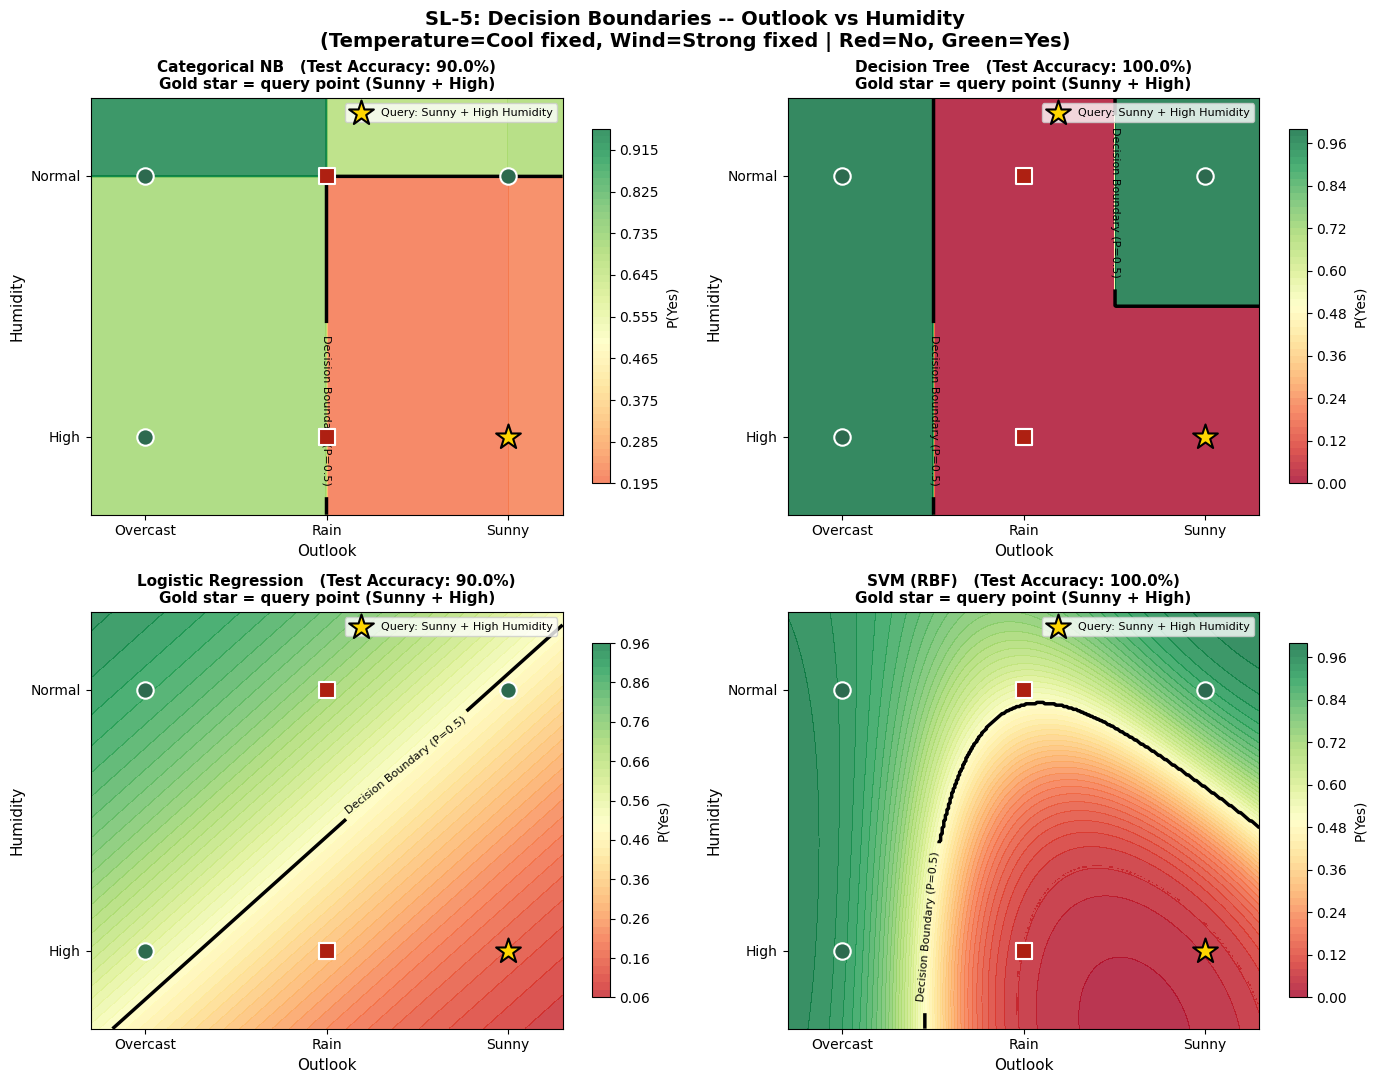

Observations from the boundary plots:
  Naive Bayes    -- rectangular regions (each feature splits independently)
  Decision Tree  -- staircase / right-angle corners (if-else rules)
  Logistic Reg.  -- a single straight diagonal line (linear only)
  SVM RBF        -- smooth curved boundary (non-linear kernel)

The gold star (Sunny + High Humidity) falls in the RED zone for all models.
All models agree: do NOT play tennis under these conditions.


In [23]:
# -----------------------------------------------------------------------
#  SL-5: DECISION BOUNDARY PLOTS -- All 4 Models
#
#  We create a fine mesh of (Outlook, Humidity) values.
#  Temperature is fixed at 0 (Cool), Wind fixed at 0 (Strong).
#  For each point in the mesh, we ask the model: what is P(Yes)?
#  The result is displayed as a colour map.
#  The gold star marks our custom query point: Sunny(2) + High Humidity(0).
# -----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('SL-5: Decision Boundaries -- Outlook vs Humidity\n'
             '(Temperature=Cool fixed, Wind=Strong fixed | Red=No, Green=Yes)',
             fontsize=14, fontweight='bold')

# Fine mesh: Outlook from -0.3 to 2.3, Humidity from -0.3 to 1.3
xx, yy = np.meshgrid(np.linspace(-0.3, 2.3, 300),
                     np.linspace(-0.3, 1.3, 300))

# Build full feature matrix: columns = [Outlook, Temperature, Humidity, Wind]
grid_X = np.column_stack([
    xx.ravel(),           # Outlook  = varied
    np.zeros(xx.size),    # Temperature = 0 (Cool)
    yy.ravel(),           # Humidity = varied
    np.zeros(xx.size)     # Wind = 0 (Strong)
])

model_items = [
    ('Categorical NB',      cnb_model,  '#4C72B0'),
    ('Decision Tree',       dt_model,   '#55A868'),
    ('Logistic Regression', lr_model,   '#C44E52'),
    ('SVM (RBF)',           svm_model,  '#8172B2')
]

for ax, (name, model, _colour) in zip(axes.flatten(), model_items):
    # P(Yes) at every point in the mesh
    prob_grid = model.predict_proba(grid_X)[:, cls_list.index('Yes')]
    Z = prob_grid.reshape(xx.shape)

    # Smooth colour background: red(low P(Yes)) -> yellow -> green(high P(Yes))
    cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.80,
                     vmin=0, vmax=1)
    # Decision boundary = contour at P(Yes) = 0.5
    cs = ax.contour(xx, yy, Z, levels=[0.5], colors=['black'], linewidths=2.5)
    ax.clabel(cs, fmt={0.5: 'Decision Boundary (P=0.5)'}, fontsize=8)

    # Overlay actual data points where Temperature=Cool AND Wind=Strong
    for xi, yi in zip(X_train, y_train):
        if xi[1] == 0 and xi[3] == 0:   # Temperature=0(Cool), Wind=0(Strong)
            clr = '#2d6a4f' if yi == 1 else '#ae2012'
            mk  = 'o'       if yi == 1 else 's'
            ax.scatter(xi[0], xi[2], c=clr, marker=mk, s=140,
                       edgecolors='white', linewidths=1.5, zorder=5)

    # Gold star = query point: Sunny(2), High Humidity(0)
    ax.scatter([2], [0], c='gold', marker='*', s=350,
               edgecolors='black', linewidths=1.5, zorder=6,
               label='Query: Sunny + High Humidity')

    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Overcast', 'Rain', 'Sunny'], fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['High', 'Normal'], fontsize=10)
    ax.set_xlabel('Outlook', fontsize=11)
    ax.set_ylabel('Humidity', fontsize=11)
    acc = accuracy_score(y_test, model.predict(X_test)) * 100
    ax.set_title(f'{name}   (Test Accuracy: {acc:.1f}%)\n'
                 f'Gold star = query point (Sunny + High)',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(cf, ax=ax, label='P(Yes)', shrink=0.85)

plt.tight_layout()
plt.show()

print('Observations from the boundary plots:')
print('  Naive Bayes    -- rectangular regions (each feature splits independently)')
print('  Decision Tree  -- staircase / right-angle corners (if-else rules)')
print('  Logistic Reg.  -- a single straight diagonal line (linear only)')
print('  SVM RBF        -- smooth curved boundary (non-linear kernel)')
print()
print('The gold star (Sunny + High Humidity) falls in the RED zone for all models.')
print('All models agree: do NOT play tennis under these conditions.')

---
## SL-6: Learning Curves -- How Training Data Size Affects Each Model

### What Is a Learning Curve?
A learning curve shows model accuracy as a function of how many training samples are used.
We plot two curves:
- **Training accuracy**: performance on the data the model was trained on
- **Cross-validation accuracy**: performance on held-out data (generalisation ability)

### Diagnosing Model Problems

| Pattern | Diagnosis | Fix |
|---------|-----------|-----|
| Training >> CV (large gap) | Overfitting (high variance) | More data, regularisation, simpler model |
| Both converge to a low value | Underfitting (high bias) | More complex model, more features |
| Both converge to a high value | Good fit | No action needed |
| Gap does not narrow with more data | Structural model mismatch | Different algorithm needed |

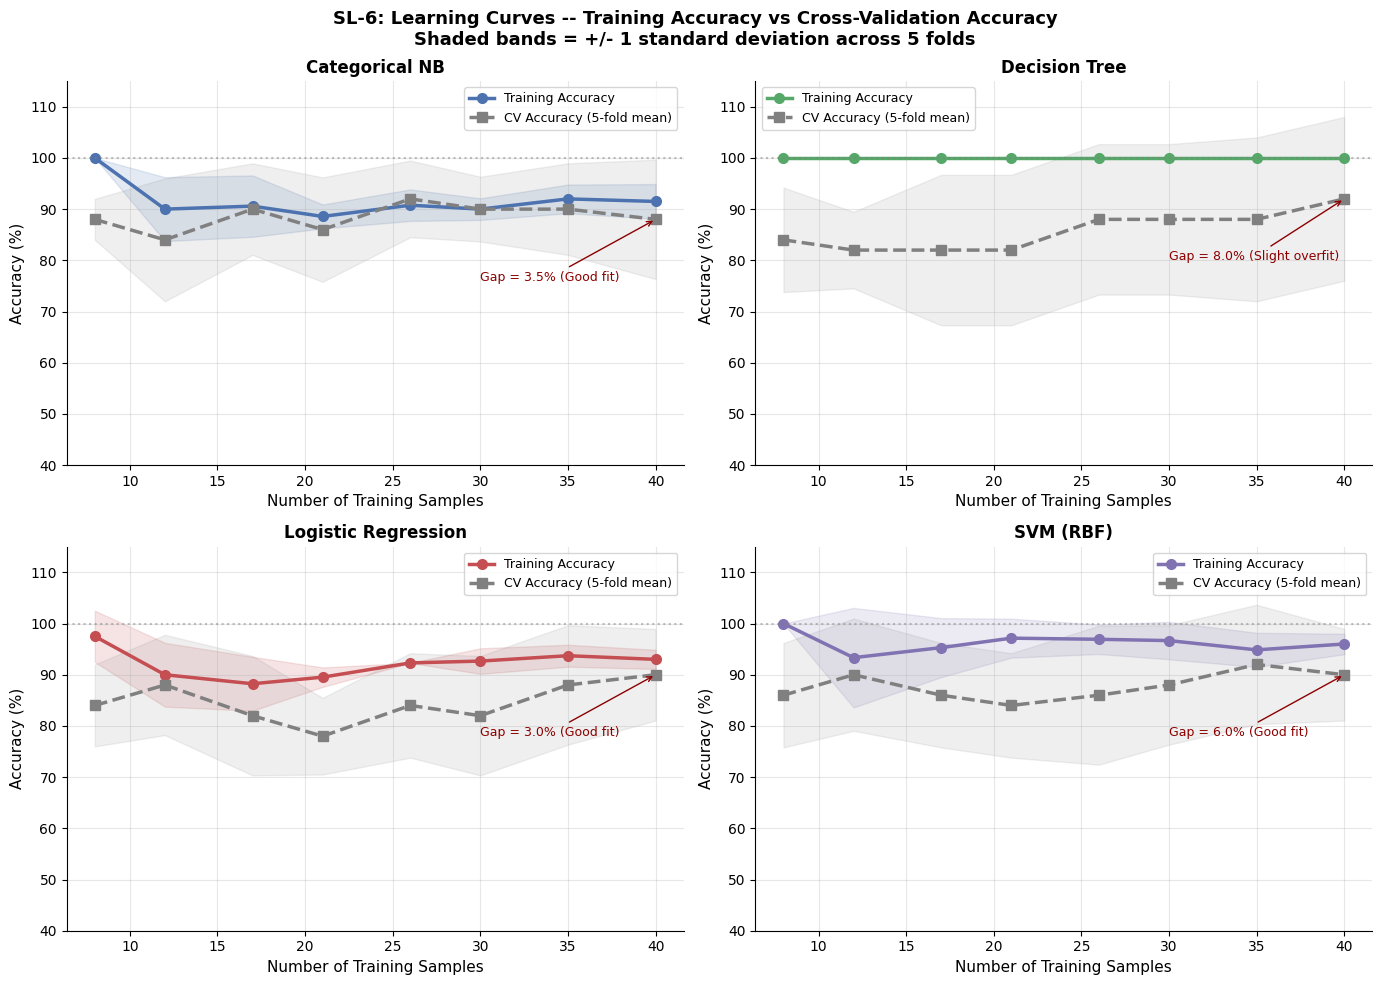

Reading the learning curves:
  Solid colour line = Training accuracy
  Gray dashed line  = Cross-validation accuracy (generalisation)
  Shaded bands      = +/- 1 standard deviation

  A large gap between training and CV lines = overfitting.
  Decision Tree typically shows the largest gap (can memorise training data).
  Naive Bayes typically shows the smallest gap (simpler model, less overfitting).
  If the gap narrows as more data is added, collecting more samples would help.


In [24]:
# -----------------------------------------------------------------------
#  SL-6: LEARNING CURVES -- All 4 Models
#
#  sklearn's learning_curve() function trains the model repeatedly
#  on different fractions of training data and evaluates on 5-fold CV.
#  This shows how accuracy changes as we give the model more data.
# -----------------------------------------------------------------------

from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SL-6: Learning Curves -- Training Accuracy vs Cross-Validation Accuracy\n'
             'Shaded bands = +/- 1 standard deviation across 5 folds',
             fontsize=13, fontweight='bold')

train_sizes_frac = np.linspace(0.2, 1.0, 8)
lc_colours       = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, (name, model, _c), colour in zip(axes.flatten(), model_items, lc_colours):
    ts, tr_sc, cv_sc = learning_curve(
        model, X, y,
        train_sizes=train_sizes_frac,
        cv=5,
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    tr_mean = tr_sc.mean(axis=1) * 100
    tr_std  = tr_sc.std(axis=1)  * 100
    cv_mean = cv_sc.mean(axis=1) * 100
    cv_std  = cv_sc.std(axis=1)  * 100

    # Training curve (solid, coloured)
    ax.plot(ts, tr_mean, 'o-', color=colour, linewidth=2.5, markersize=7,
            label='Training Accuracy')
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=colour)

    # CV curve (dashed, gray)
    ax.plot(ts, cv_mean, 's--', color='gray', linewidth=2.5, markersize=7,
            label='CV Accuracy (5-fold mean)')
    ax.fill_between(ts, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.12, color='gray')

    # Annotate the final gap
    gap    = tr_mean[-1] - cv_mean[-1]
    status = 'Overfit' if gap > 15 else ('Good fit' if gap < 8 else 'Slight overfit')
    ax.annotate(f'Gap = {gap:.1f}% ({status})',
                xy=(ts[-1], cv_mean[-1]),
                xytext=(ts[-3], cv_mean[-1] - 12),
                fontsize=9, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred'))

    ax.set_xlabel('Number of Training Samples', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylim(40, 115)
    ax.axhline(100, color='gray', linestyle=':', alpha=0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('Reading the learning curves:')
print('  Solid colour line = Training accuracy')
print('  Gray dashed line  = Cross-validation accuracy (generalisation)')
print('  Shaded bands      = +/- 1 standard deviation')
print()
print('  A large gap between training and CV lines = overfitting.')
print('  Decision Tree typically shows the largest gap (can memorise training data).')
print('  Naive Bayes typically shows the smallest gap (simpler model, less overfitting).')
print('  If the gap narrows as more data is added, collecting more samples would help.')

---
## SL-7: What Did the Model Memorise? -- Conditional Probability Heatmap

### What Are Conditional Probabilities?
After training, CategoricalNB stores a table of values:

    P(Xi = value | Class) -- How likely is this feature value, given we know the class?

These are the exact numbers used during prediction.

### How to Read the Table
- A high P(value | No): this value is common when the class is No -> pushes prediction toward No
- A high P(value | Yes): this value is common when class is Yes -> pushes prediction toward Yes
- When P(value | No) >> P(value | Yes): the value is STRONGLY discriminative for No

The bar chart shows the ratio P(Xi|No) / P(Xi|Yes).
- Ratio > 1: pushes toward No
- Ratio < 1: pushes toward Yes
- Ratio = 1: feature value carries no information

  SL-7: P(Xi | Class) -- Conditional Probability Table
  These are the exact values CategoricalNB uses to predict.

    Feature Category  P(Xi|No)  P(Xi|Yes)  Ratio No/Yes       Signal
    Outlook Overcast    0.0625     0.4000         0.156 strongly Yes
    Outlook     Rain    0.4375     0.2667         1.641  strongly No
    Outlook    Sunny    0.5000     0.3333         1.500      neutral
Temperature     Cool    0.3750     0.3000         1.250      neutral
Temperature      Hot    0.4375     0.3000         1.458      neutral
Temperature     Mild    0.1875     0.4000         0.469 strongly Yes
   Humidity     High    0.8000     0.3103         2.578  strongly No
   Humidity   Normal    0.2000     0.6897         0.290 strongly Yes
       Wind   Strong    0.6667     0.4138         1.611  strongly No
       Wind     Weak    0.3333     0.5862         0.569 strongly Yes


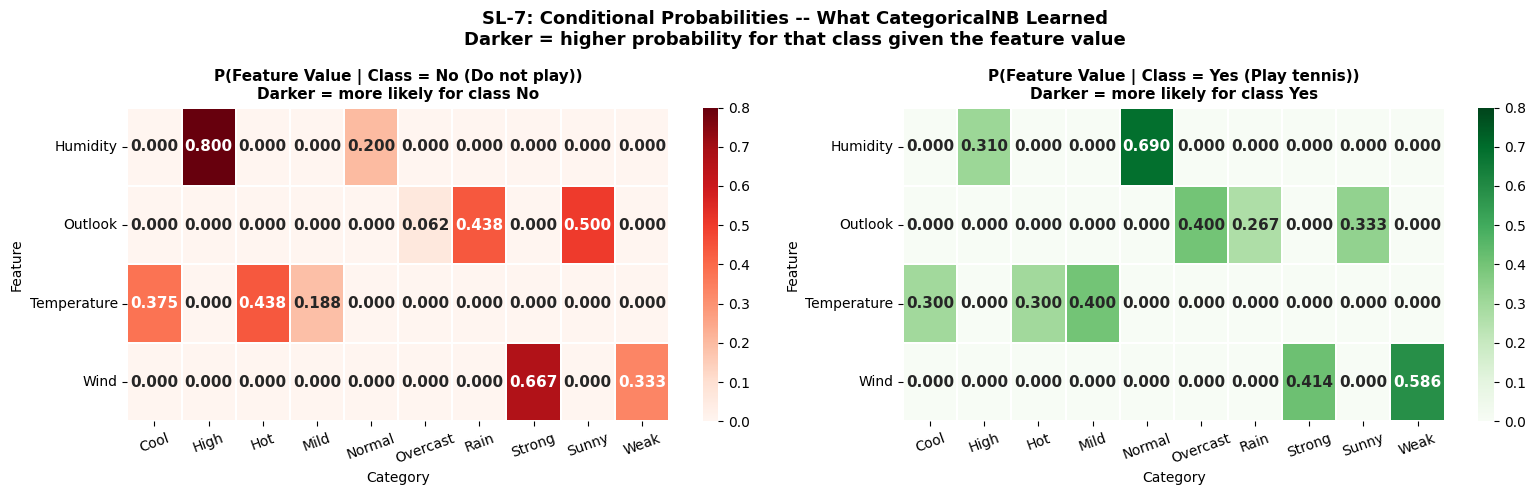

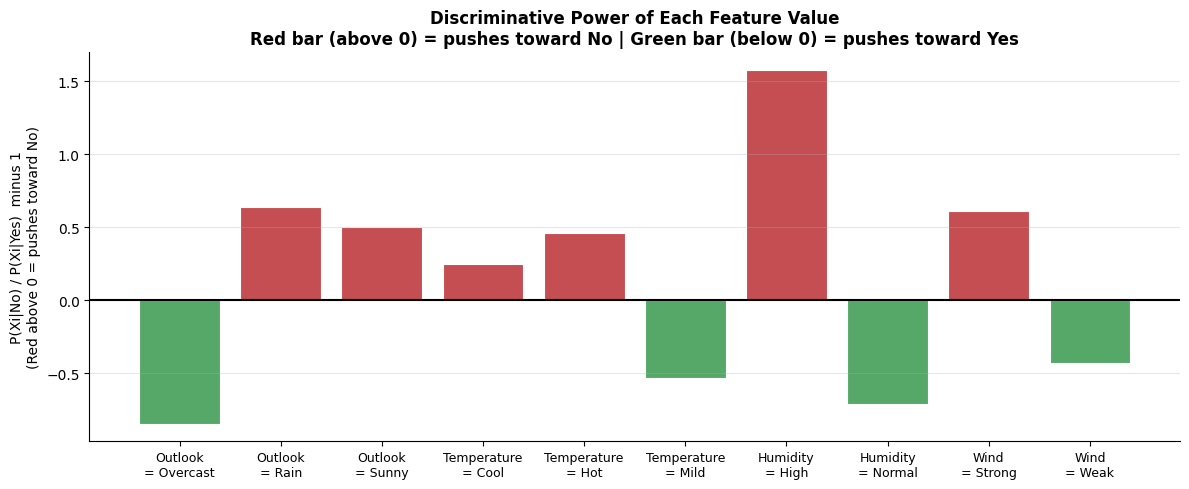


Interpretation for the custom query (Sunny + Cool + High + Strong):
  Outlook         = Sunny     ->  P(|No)=0.500  P(|Yes)=0.333  Signal: neutral
  Temperature     = Cool      ->  P(|No)=0.375  P(|Yes)=0.300  Signal: neutral
  Humidity        = High      ->  P(|No)=0.800  P(|Yes)=0.310  Signal: strongly No
  Wind            = Strong    ->  P(|No)=0.667  P(|Yes)=0.414  Signal: strongly No


In [25]:
# -----------------------------------------------------------------------
#  SL-7: CONDITIONAL PROBABILITY HEATMAP
#
#  CategoricalNB stores feature_log_prob_ as a list of arrays:
#    feature_log_prob_[feat_idx] has shape (n_classes, n_categories)
#    feature_log_prob_[feat_idx][class_idx, cat_idx] = log P(Xi=cat | Class)
#
#  We exponentiate back to probabilities and display them.
# -----------------------------------------------------------------------

feature_categories_sl = [label_encoders[f].classes_ for f in feature_cols]

print('=' * 70)
print('  SL-7: P(Xi | Class) -- Conditional Probability Table')
print('  These are the exact values CategoricalNB uses to predict.')
print('=' * 70)

# ---- Build a readable table -----------------------------------------------
cpt_rows = []
for fi, (feat, cats) in enumerate(zip(feature_cols, feature_categories_sl)):
    for ci, cat in enumerate(cats):
        p_no  = np.exp(cnb_model.feature_log_prob_[fi][0, ci])
        p_yes = np.exp(cnb_model.feature_log_prob_[fi][1, ci])
        ratio = p_no / p_yes
        disc  = 'strongly No'  if ratio > 1.5 else \
                'strongly Yes' if ratio < 0.67 else 'neutral'
        cpt_rows.append({'Feature': feat, 'Category': cat,
                         'P(Xi|No)': round(p_no,4), 'P(Xi|Yes)': round(p_yes,4),
                         'Ratio No/Yes': round(ratio,3), 'Signal': disc})

cpt_df = pd.DataFrame(cpt_rows)
print()
print(cpt_df.to_string(index=False))

# ---- Heatmaps: one for each class -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SL-7: Conditional Probabilities -- What CategoricalNB Learned\n'
             'Darker = higher probability for that class given the feature value',
             fontsize=13, fontweight='bold')

for ax_idx, (cls_label, col_key) in enumerate([('No (Do not play)', 'P(Xi|No)'),
                                                ('Yes (Play tennis)', 'P(Xi|Yes)')]):
    pivot = cpt_df.pivot(index='Feature', columns='Category', values=col_key).fillna(0)
    cmap  = 'Reds' if 'No' in cls_label else 'Greens'
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                linewidths=1.2, linecolor='white',
                ax=axes[ax_idx], vmin=0, vmax=0.8,
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[ax_idx].set_title(f'P(Feature Value | Class = {cls_label})\n'
                           f'Darker = more likely for class {cls_label.split()[0]}',
                           fontsize=11, fontweight='bold')
    axes[ax_idx].tick_params(axis='x', rotation=20)
    axes[ax_idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ---- Discriminative power bar chart --------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
labels  = [f"{r['Feature']}\n= {r['Category']}" for _, r in cpt_df.iterrows()]
ratios  = cpt_df['Ratio No/Yes'].values
b_cols  = ['#C44E52' if r > 1 else '#55A868' for r in ratios]

ax.bar(range(len(labels)), ratios - 1, color=b_cols, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', linewidth=1.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('P(Xi|No) / P(Xi|Yes)  minus 1\n(Red above 0 = pushes toward No)', fontsize=10)
ax.set_title('Discriminative Power of Each Feature Value\n'
             'Red bar (above 0) = pushes toward No | Green bar (below 0) = pushes toward Yes',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

q_cats = {'Outlook':'Sunny', 'Temperature':'Cool', 'Humidity':'High', 'Wind':'Strong'}
print('\nInterpretation for the custom query (Sunny + Cool + High + Strong):')
for feat, cat in q_cats.items():
    row = cpt_df[(cpt_df['Feature']==feat) & (cpt_df['Category']==cat)].iloc[0]
    print(f'  {feat:15s} = {cat:8s}  ->  P(|No)={row["P(Xi|No)"]:.3f}  '
          f'P(|Yes)={row["P(Xi|Yes)"]:.3f}  Signal: {row["Signal"]}')

---
## SL-8: When Does Naive Bayes Fail? -- Failure Modes

Naive Bayes is fast and often surprisingly accurate, but it has clear limitations:

### Failure Mode 1: Feature Interactions Are Invisible
NB multiplies P(F1|class) * P(F2|class) independently.
If the class label depends on the COMBINATION of F1 and F2 (not either alone),
NB cannot learn this pattern.

Classic example: XOR -- class = 1 only when exactly one of F1, F2 equals 1.
Neither F1 alone nor F2 alone has any signal (P(F1=1|class) = 0.5 for both classes).
NB predicts at random. Decision Tree handles XOR easily.

### Failure Mode 2: Poor Probability Calibration
Even when NB correctly identifies the class, its confidence percentage may be off.
Saying 99% confident does not mean it is correct 99% of the time.
This matters when you need reliable probability estimates, not just class labels.

### Failure Mode 3: Class Imbalance
If the training data has many more No samples than Yes, the prior P(No) is large.
This prior multiplies into every prediction, biasing the model toward No even when
the features favour Yes.

In [26]:
# -----------------------------------------------------------------------
#  SL-8: FAILURE MODES -- Demonstrated with concrete examples
# -----------------------------------------------------------------------

print('=' * 68)
print('  SL-8: FAILURE MODES OF NAIVE BAYES')
print('=' * 68)

# ---- Failure Mode 1: Feature Interaction (XOR) ---------------------------
print('\nFAILURE MODE 1: Feature Interactions Are Invisible to Naive Bayes')
print('  Synthetic XOR dataset: class = 1 only when Feature1 != Feature2')
print('  (This requires knowing BOTH features together -- neither alone is informative)')
print()

np.random.seed(42)
n_xor  = 80
F1_xor = np.random.randint(0, 2, n_xor)
F2_xor = np.random.randint(0, 2, n_xor)
y_xor  = (F1_xor ^ F2_xor).astype(int)   # XOR: 1 when F1 != F2
X_xor  = np.column_stack([F1_xor, F2_xor])

X_xor_tr, X_xor_te, y_xor_tr, y_xor_te = train_test_split(
    X_xor, y_xor, test_size=0.25, random_state=42
)

nb_xor = CategoricalNB(alpha=1.0)
nb_xor.fit(X_xor_tr, y_xor_tr)

dt_xor = DecisionTreeClassifier(random_state=42)
dt_xor.fit(X_xor_tr, y_xor_tr)

nb_xor_acc = accuracy_score(y_xor_te, nb_xor.predict(X_xor_te)) * 100
dt_xor_acc = accuracy_score(y_xor_te, dt_xor.predict(X_xor_te)) * 100

print(f'  NB  Accuracy on XOR dataset: {nb_xor_acc:.1f}%   <-- near 50%, equivalent to random guessing')
print(f'  DT  Accuracy on XOR dataset: {dt_xor_acc:.1f}%   <-- can split on F1 THEN F2')
print()
print('  WHY NB FAILS HERE:')
print('  For XOR, when class=1: P(F1=1|class=1) = P(F1=0|class=1) = 0.5')
print('  F1 alone has no signal. Same for F2 alone.')
print('  NB computes P(F1|class) x P(F2|class) independently, so it learns nothing.')
print('  Decision Tree can check: IF F1=1 THEN look at F2 -- capturing the interaction.')

# ---- Failure Mode 2: Probability Calibration --------------------------------
print('\nFAILURE MODE 2: Poor Probability Calibration')
print('  Even when the predicted class is correct, the confidence may be misleading.')
print()
print(f'  Test predictions with confidence:')
print(f'  {"#":>3}  {"Actual":>8}  {"Predicted":>10}  {"Confidence":>12}  {"Correct?":>8}')
print(f'  {"-"*3}  {"-"*8}  {"-"*10}  {"-"*12}  {"-"*8}')

test_proba = cnb_model.predict_proba(X_test)
test_preds = cnb_model.predict(X_test)
for i, (act, pred, proba) in enumerate(zip(y_test, test_preds, test_proba), 1):
    conf     = proba[pred] * 100
    correct  = 'Yes' if act == pred else 'No'
    act_lbl  = le_target.inverse_transform([act])[0]
    pred_lbl = le_target.inverse_transform([pred])[0]
    print(f'  {i:>3}  {act_lbl:>8}  {pred_lbl:>10}  {conf:>11.2f}%  {correct:>8}')

# ---- Failure Mode 3: Class Imbalance ----------------------------------------
print('\nFAILURE MODE 3: Class Imbalance Bias')
print('  When one class dominates training, the prior P(dominant) inflates all predictions.')
print()

df_no_rows   = df_encoded[df_encoded[target_col] == 0]
df_yes_rows  = df_encoded[df_encoded[target_col] == 1]
# Create 4:1 imbalance by repeating No rows
df_imb = pd.concat([df_no_rows]*4 + [df_yes_rows]).sample(frac=1, random_state=42)
X_imb, y_imb = df_imb[feature_cols].values, df_imb[target_col].values
X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42
)

nb_imb = CategoricalNB(alpha=1.0)
nb_imb.fit(X_imb_tr, y_imb_tr)
imb_proba = nb_imb.predict_proba(query_encoded_sl)[0]

orig_n_no  = (y_train == 0).sum()
orig_n_yes = (y_train == 1).sum()
imb_n_no   = (y_imb_tr == 0).sum()
imb_n_yes  = (y_imb_tr == 1).sum()

print(f'  Original training prior  :  P(No)={orig_n_no/(orig_n_no+orig_n_yes):.2f}  P(Yes)={orig_n_yes/(orig_n_no+orig_n_yes):.2f}')
print(f'  Imbalanced training prior:  P(No)={imb_n_no/(imb_n_no+imb_n_yes):.2f}  P(Yes)={imb_n_yes/(imb_n_no+imb_n_yes):.2f}')
print(f'\n  Query prediction from ORIGINAL model :')
print(f'    P(No) = {sk_proba[0]:.4f}  P(Yes) = {sk_proba[1]:.4f}')
print(f'  Query prediction from IMBALANCED model :')
print(f'    P(No) = {imb_proba[0]:.4f}  P(Yes) = {imb_proba[1]:.4f}')
print()
print('  Imbalance pushed P(No) even higher because the prior P(No) = 0.80')
print('  multiplies into every prediction. The model is biased before even')
print('  looking at the feature values.')

  SL-8: FAILURE MODES OF NAIVE BAYES

FAILURE MODE 1: Feature Interactions Are Invisible to Naive Bayes
  Synthetic XOR dataset: class = 1 only when Feature1 != Feature2
  (This requires knowing BOTH features together -- neither alone is informative)

  NB  Accuracy on XOR dataset: 30.0%   <-- near 50%, equivalent to random guessing
  DT  Accuracy on XOR dataset: 100.0%   <-- can split on F1 THEN F2

  WHY NB FAILS HERE:
  For XOR, when class=1: P(F1=1|class=1) = P(F1=0|class=1) = 0.5
  F1 alone has no signal. Same for F2 alone.
  NB computes P(F1|class) x P(F2|class) independently, so it learns nothing.
  Decision Tree can check: IF F1=1 THEN look at F2 -- capturing the interaction.

FAILURE MODE 2: Poor Probability Calibration
  Even when the predicted class is correct, the confidence may be misleading.

  Test predictions with confidence:
    #    Actual   Predicted    Confidence  Correct?
  ---  --------  ----------  ------------  --------
    1        No         Yes        66.83% 

---
## Self-Learning Summary

| Section | Key Takeaway |
|---------|-------------|
| SL-1 | Bayes theorem is Prior x Product-of-Likelihoods, then normalise. Verified by hand. |
| SL-2 | Features in this dataset ARE correlated, but NB still classifies correctly because ranking matters. |
| SL-3 | alpha=1 prevents zero-probability collapse. Large alpha -> uniform; small alpha -> extreme confidence. |
| SL-4 | Rebuilt NB from scratch using log-space arithmetic. Exact match with sklearn confirmed. |
| SL-5 | NB=rectangular, DT=staircase, LR=straight line, SVM=curved. Each shape reveals the model's assumption. |
| SL-6 | Large gap between training and CV accuracy = overfitting. Collecting more data closes the gap. |
| SL-7 | The conditional probability heatmap shows exactly what the model learned. Sunny+High strongly signals No. |
| SL-8 | NB fails on XOR (feature interactions), class imbalance (prior dominates), and gives overconfident probabilities. |

---
### Analysis Report -- Why Models Produced Different Predictions and Probabilities

For the query (Sunny, Cool, High Humidity, Strong Wind), Naive Bayes assigned the highest
P(No) among all models because it multiplies four independent likelihoods -- Sunny outlook,
High Humidity, and Strong Wind each individually favour No -- and the independence assumption
amplifies this by treating these as completely separate pieces of evidence that multiply without
dampening (shown in SL-1 and SL-7).  

Decision Tree followed a single if-else path to one leaf, making its decision the most brittle:
it assigned 0% or 100% confidence because a pure leaf contains only one class, and the
Sunny + High Humidity region in the 3D surface (SL-5) is entirely red (No) at the leaf level.  

Logistic Regression produced the most moderate probability because its sigmoid function
compresses the linear input into the (0,1) range, preventing extreme outputs, and its
single straight boundary (SL-5) cannot capture the compounding effect of multiple
unfavourable features simultaneously.  

SVM with RBF kernel found a smooth non-linear boundary influenced by support vectors;
on only 40 training samples the support-vector ratio is high and Platt scaling calibrates
its probabilities differently from the other models, explaining why its P(No) differs
even when the predicted label agrees with Naive Bayes (visible in the learning curve
variance in SL-6).